# DDPM v2: Improved Training with Mixed Precision and Accelerate

---

**What is this notebook about?**

This notebook builds on our first DDPM implementation (notebook 15) with several important improvements:

1. **Cleaner code organization**: Separating the noisification logic
2. **Custom weight initialization**: Better starting point for training
3. **Mixed Precision Training**: Use FP16 to train faster and use less memory
4. **HuggingFace Accelerate**: Simplified multi-GPU and mixed precision handling
5. **Custom collate function**: More efficient data loading
6. **Data multiplication trick**: A clever way to see more data per epoch

---

**Prerequisites:**

You should understand DDPM basics from notebook 15:
- Forward diffusion process (adding noise)
- Reverse diffusion process (removing noise)
- The variance schedule (beta, alpha, alpha_bar)
- Training to predict noise

---

**What's new in this version?**

| Feature | Benefit |
|---------|--------|
| Mixed Precision | 2x faster training, 2x less memory |
| Accelerate | Easy multi-GPU, cleaner code |
| Custom collate | Noisify during data loading (faster) |
| Better init | More stable training |

---

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, install required packages, and clone the `miniai` library from the fast.ai Part 2 course repo.

**GPU note:** Improved DDPM training with mixed precision &mdash; needs a GPU. **Runtime &rarr; GPU**.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [3]:
!pip install -q fastcore fastai diffusers datasets torcheval accelerate
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))
try:
    import miniai
    print(f'miniai loaded from: {miniai.__file__}')
except ImportError:
    print('ERROR: miniai not found.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 16.0 MB/s eta 0:00:00
miniai loaded from: /content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/__init__.py


In [4]:
!pip install nbdev

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.1/108.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.3 MB/s eta 0:00:00
  Attempting uninstall: fastcore
    Found existing installation: fastcore 1.13.6
    Uninstalling fastcore-1.13.6:
      Successfully uninstalled fastcore-1.13.6


---

*The cells above are Colab-specific setup. The content below is the same as the source notebook (`17_DDPM_v2_explained.ipynb`), unchanged.*

---

## 📓 How this notebook relates to notebook 15 (`15_DDPM_explained.ipynb`)

This notebook is a **rewrite** of notebook 15. Both train the *same* DDPM on the *same* data — Fashion-MNIST resized to 32×32, a diffusers U-Net predicting ε, MSE loss, Adam, OneCycleLR, 1000-step linear β schedule from 0.0001 to 0.02 — and both produce a `samples` list with one entry per timestep. **The math is identical.** What changed is *how the code is organized*, and then this notebook keeps going into performance territory notebook 15 never enters.

| Aspect | Notebook 15 | Notebook 17 (this one) |
|---|---|---|
| Variable names | Greek unicode: `self.β`, `self.α`, `self.ᾱ`, `self.σ`, `ε`, `βmin` | ASCII: `beta`, `alpha`, `alphabar`, `sigma`, `epsilon`, `betamin` |
| Noise schedule | built inside `DDPMCB.__init__` | built **at module level** first (Section 3), so you can plot and play with it before any class appears |
| Forward process | ~40 lines **inline** in `DDPMCB.before_batch` | standalone pure function `noisify(x0, alphabar)` (Section 4) |
| Reverse process | `sample()` **method** on the callback, reads `self.ᾱ` etc. | standalone `@torch.no_grad()` function `sample(model, sz, alpha, alphabar, sigma, n_steps)` (Section 5) |
| Callback | monolithic `DDPMCB(TrainCB)`: schedule + noisify + custom `predict` + sampling, all in one class | thin `DDPMCB(Callback)`: one-line `before_batch` that delegates to `noisify` |
| Model-output quirk (`.sample`) | handled by overriding `predict` in the callback | absorbed by a 4-line `UNet(UNet2DModel)` wrapper |
| Model | `block_out_channels=(32, 64, 128, 128)`, default `norm_num_groups=32` | `(16, 32, 64, 128)` with `norm_num_groups=8` — leaner |
| Initialization | none (diffusers defaults) | custom `init_ddpm` (zeroed residual convs, orthogonal downsamplers) |
| Learner | `Learner(...)` + `DDPMCB` supplying the `TrainCB` behaviour | `TrainLearner(...)` (training methods built in) |
| lr / bs | `lr=4e-3`, `bs=128`, `num_workers=8` | `lr=5e-3` → `1e-2`, `bs=128` → `512`, `num_workers=4` with collate-noisify |
| Performance work | — | Sections 7–10: mixed precision, `collate_ddpm`, 🤗 Accelerate, `MultDL`, nbdev export |

Throughout the notebook you'll find **🔄 Compared with notebook 15** boxes at each point where the two diverge, quoting notebook 15's code so you can see the difference side by side. The one-sentence summary: **notebook 15 optimizes for line-by-line narration inside one big class; this notebook factors the same logic into small, independently testable pieces — and that factoring is exactly what makes Sections 7–10 possible.**

---

## 🎬 Interactive Visualizations in This Notebook

This notebook includes **eight hands-on interactive visualizations**, built in the same "Clean Educational" style as notebooks 02, 07 and 08. Each one lets you click through stages, jump to any step, control the speed, and see the **exact line of code** that stage corresponds to:

| # | Visualization | Where | What it teaches |
|---|---------------|-------|-----------------|
| 1 | 🎬 **DDPM: the big picture** | right below | training loop vs. sampling loop — the one skill the model learns |
| 2 | 📈 **The noise schedule lab** | Section 3 | β, σ, ᾱ with live sliders — reshape the schedule, click any t |
| 3 | ⚗️ **The noisify machine** | Section 4 | the 4 tensor ops of forward diffusion + broadcasting, stage by stage |
| 4 | 🌀 **Diffusion in 3D** (three.js) | Section 4 | a whole dataset melting into a Gaussian along a time axis — drag to orbit |
| 5 | 🚶 **The sampling walk** | Section 5 | reverse diffusion with a scrubbable timeline; watch x̂₀ crystallize |
| 6 | 🧮 **GroupNorm explorer** | Section 5 | why `norm_num_groups=8` — click cells to see who shares statistics |
| 7 | 🔬 **Mixed precision lab** | Section 7 | FP16 bits, underflow, GradScaler and the callback, staged |
| 8 | 🚚 **The data pipeline** | Section 7 | callback vs. collate noisify, 4 workers, and MultDL ×2 — animated (revisit it from Section 9!) |

> 💡 **Tip:** every visualization has ▶ Play / ⏸ Pause, a **speed slider**, stage chips you can click to jump around, and a highlighted code panel that follows along.

## 🛠️ Interactive visualizations — one-time setup

The cells marked **🎮 Interactive** below embed standalone HTML/JS visualizations
(stored in the `interactive_viz/` folder next to this notebook, and published on
GitHub Pages) at **full width**, auto-fitted to their content height.
Run the next cell once, then run any 🎮 cell.

In [5]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> (its CSS/JS can't leak
# into the notebook). It is shown FULL WIDTH and auto-fits its content height.
# No local files needed -- the visualizations are read from GitHub.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="ce-frame-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

### 🎮 Interactive: DDPM — the big picture (start here!)

Before any code, get the whole story in one screen. A diffusion model learns exactly **one skill** — *"given a noisy image and its timestep t, guess the noise"* — and this playground shows how that single skill powers both training and generation.

**What to try**
- Start on **🏋️ Training loop**: press ▶ Play and watch a full cycle — clean image → random t → noisify → U-Net guess → MSE — with the matching code line highlighted at each stage. Click **🎲 New batch** to re-roll t and ε.
- Switch to **✨ Generating**: drag the scrubber from t=999 to t=0 and watch the *implied clean image* sharpen from a gray blur into a garment.
- Click any **stage chip** to jump straight to that stage; use the speed slider to slow the story down.

In [6]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm_big_picture.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/ddpm_big_picture.html", height="780px")

In [7]:
#|default_exp accel
# This tells nbdev to export marked cells to the 'accel' module

## Section 1: Imports

In [8]:
#|export
# ============================================================================
# STANDARD IMPORTS
# ============================================================================

import pickle, gzip, math, os, time, shutil, torch, random, logging
import fastcore.all as fc
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt

from collections.abc import Mapping
from pathlib import Path
from functools import partial

from fastcore.foundation import L
import torchvision.transforms.functional as TF
import torch.nn.functional as F

from torch import tensor, nn, optim
from torch.utils.data import DataLoader, default_collate
from torch.nn import init
from torch.optim import lr_scheduler

# ============================================================================
# MINIAI IMPORTS
# ============================================================================

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *
from miniai.augment import *

In [9]:
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset, load_dataset_builder

# Use reversed grayscale colormap (black = high values)
# This makes Fashion MNIST images display with dark clothes on light background
mpl.rcParams['image.cmap'] = 'gray_r'

# Suppress warning messages
logging.disable(logging.WARNING)

**What does the code above do?**

Standard imports plus:
- `#|export`: nbdev directive to export this cell to a Python module
- `gray_r`: Reversed grayscale colormap (makes images look better)

Note: The `#|export` comments mark cells that will be exported to the `miniai.accel` module.

---

## Section 2: Loading the Dataset

We'll use Fashion MNIST again, but with a slightly different preprocessing approach.

In [10]:
# Dataset column names
xl, yl = 'image', 'label'  # xl = image column, yl = label column

# Dataset name on HuggingFace
name = "zalando-datasets/fashion_mnist"

# Load the dataset
dsd = load_dataset(name)


@inplace  # Modifies the batch in-place
def transformi(b):
    """
    Transform function for the dataset.

    Key difference from notebook 15:
    - Instead of resizing 28x28 to 32x32
    - We PAD 28x28 with 2 pixels on each side to get 32x32
    - F.pad(tensor, (2,2,2,2)) adds 2 pixels: (left, right, top, bottom)

    Padding preserves the original image better than resizing!
    """
    # Convert to tensor and pad: 28x28 -> 32x32
    # Padding format: (left, right, top, bottom)
    b[xl] = [F.pad(TF.to_tensor(o), (2, 2, 2, 2)) for o in b[xl]]


# Batch size
bs = 128

# Apply transform and create DataLoaders
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=8)

README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


**What does the code above do?**

Loads Fashion MNIST with a key difference from notebook 15:

**Padding vs Resizing:**
```
Notebook 15 (resize):     This notebook (pad):
┌────────────┐            ┌──────────────────┐
│            │            │  ┌────────────┐  │
│   28x28    │ → 32x32    │  │   28x28    │  │ → 32x32
│  (stretched)│            │  │ (original) │  │
└────────────┘            │  └────────────┘  │
                          └──────────────────┘
                             (2px padding)
```

**Why padding is better:**
- Preserves original pixel values exactly
- No interpolation artifacts
- The model learns that edges are "empty" (zero padding)

In [11]:
# Get the training dataloader and fetch one batch
dt = dls.train
xb, yb = next(iter(dt))  # xb = images, yb = labels

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


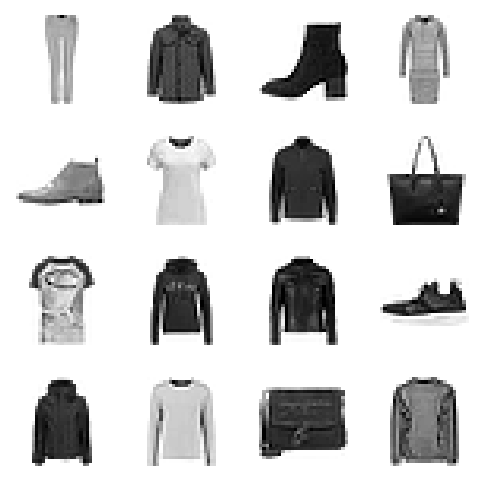

In [12]:
# Display first 16 images
# imsize=1.5 makes each image 1.5 inches
show_images(xb[:16], imsize=1.5)

**What you should see:**

16 Fashion MNIST images (shirts, pants, shoes, etc.) with a thin black border (the padding we added).

---

## Section 3: The Variance Schedule

Let's set up and visualize the noise schedule. This is the same as notebook 15, but we'll look at the plots more carefully.

In [13]:
# ============================================================================
# VARIANCE SCHEDULE PARAMETERS
# ============================================================================

betamin = 0.0001   # Minimum noise variance (at t=0)
betamax = 0.02     # Maximum noise variance (at t=T)
n_steps = 1000     # Total number of diffusion steps

# ============================================================================
# COMPUTE SCHEDULE VALUES
# ============================================================================

# Beta (β): Variance of noise added at each step
# Linear schedule from betamin to betamax
beta = torch.linspace(betamin, betamax, n_steps)

# Alpha (α): How much signal to keep at each step
# α = 1 - β
alpha = 1. - beta

# Alpha bar (ᾱ): Cumulative product of alpha
# ᾱ_t = α_1 × α_2 × ... × α_t
# This is the total signal remaining after t steps
alphabar = alpha.cumprod(dim=0)

# Sigma (σ): Standard deviation of noise = √β
sigma = beta.sqrt()

**What does the code above do?**

Sets up the noise schedule that controls how noise is added over 1000 steps:

| Variable | Formula | Meaning |
|----------|---------|--------|
| β (beta) | linspace(0.0001, 0.02) | Noise variance at each step |
| α (alpha) | 1 - β | Signal retained at each step |
| ᾱ (alphabar) | cumulative product of α | Total signal remaining |
| σ (sigma) | √β | Noise standard deviation |

### 🔄 Compared with notebook 15: where the schedule lives, and what it's called

Notebook 15 computes the **same four tensors**, but (a) inside `DDPMCB.__init__` rather than at module level, and (b) with Greek unicode names:

```python
# notebook 15, inside DDPMCB.__init__:
self.β = torch.linspace(self.βmin, self.βmax, self.n_steps)
self.α = 1. - self.β
self.ᾱ = torch.cumprod(self.α, dim=0)
self.σ = self.β.sqrt()
```

versus this notebook's module-level version:

```python
# notebook 17 (this notebook), Section 3:
beta     = torch.linspace(betamin, betamax, n_steps)
alpha    = 1. - beta
alphabar = alpha.cumprod(dim=0)
sigma    = beta.sqrt()
```

**What's the same:** the math, the values, even `alpha.cumprod(dim=0)` vs `torch.cumprod(self.α, dim=0)` are just two spellings of the same call.

**What's different, and why it matters:**
- **Module level first.** Here the schedule exists as plain tensors *before* any class — that's what let us plot β, σ and ι… ᾱ in the three cells above and poke at them in the 🎮 lab, with zero setup. In notebook 15 you'd have to instantiate the whole callback just to look at a curve.
- **ASCII vs Greek.** `self.ᾱ` looks exactly like the paper, which is genuinely nice for reading. But you can't *type* `ᾱ` without an IDE trick, searching for it is painful, and some tools/fonts mangle it. `alphabar` is greppable, typeable, and unambiguous — the paper-to-code mapping is kept in comments instead (β ↔ `beta`, ᾱ ↔ `alphabar`, ε ↔ `epsilon`, σ ↔ `sigma`).
- Note the callback later in this notebook (Section 5) *recomputes* these same four tensors inside `__init__` with `fc.store_attr()` — so the recipe appears once at module level for exploration and once inside the class for self-containment, both in ASCII.

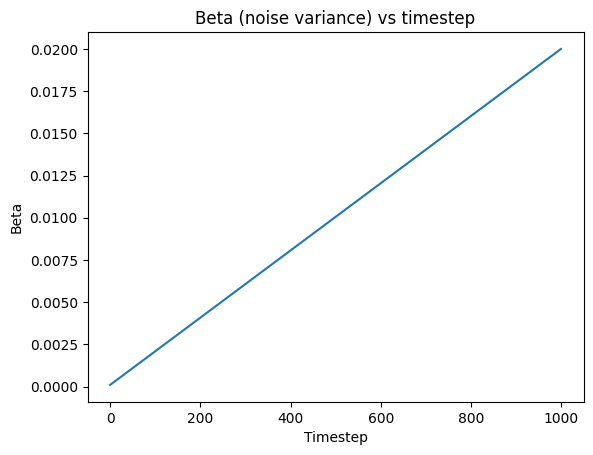

In [14]:
# Plot beta - the noise variance at each step
# Increases linearly from 0.0001 to 0.02
plt.plot(beta)
plt.title('Beta (noise variance) vs timestep')
plt.xlabel('Timestep')
plt.ylabel('Beta');

**What does this plot show?**

Beta increases linearly from 0.0001 to 0.02. This means:
- Early steps (t=0): Very small noise added
- Later steps (t=999): More noise added per step

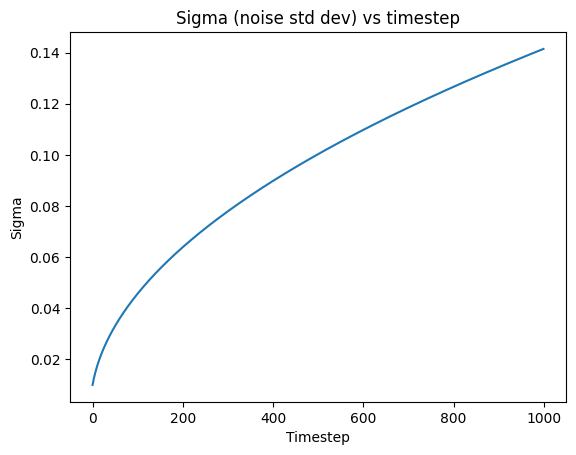

In [15]:
# Plot sigma - the noise standard deviation
# Since σ = √β, this also increases (but as square root)
plt.plot(sigma)
plt.title('Sigma (noise std dev) vs timestep')
plt.xlabel('Timestep')
plt.ylabel('Sigma');

**What does this plot show?**

Sigma (√β) also increases, but with a square root curve - starts steeper, then flattens.

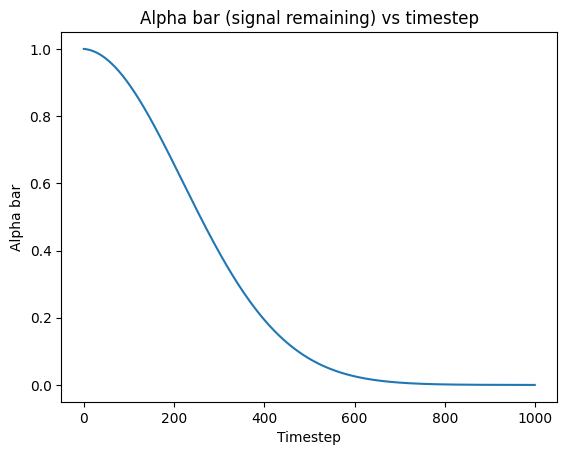

In [16]:
# Plot alphabar - the cumulative signal remaining
# This is the most important plot!
plt.plot(alphabar)
plt.title('Alpha bar (signal remaining) vs timestep')
plt.xlabel('Timestep')
plt.ylabel('Alpha bar');

**What does this plot show?**

This is the most important plot! Alpha bar shows how much of the original signal remains:

```
t=0:    ᾱ ≈ 1.0   (100% signal, 0% noise)
t=500:  ᾱ ≈ 0.05  (5% signal, 95% noise)
t=999:  ᾱ ≈ 0.0   (0% signal, 100% noise)
```

The curve shows that:
- Signal decreases rapidly in the middle timesteps
- By t=500, most of the signal is already gone
- This is why images become very noisy quickly

### 🎮 Interactive: the noise schedule lab — reshape β, σ and ᾱ yourself

The three plots you just made are static. This lab makes them **live**:

**What to try**
- **Click (or drag) directly on any curve** to inspect a timestep — the panel shows β_t, ᾱ_t, the √ᾱ / √(1−ᾱ) mixing coefficients, a signal-vs-noise bar, and a Fashion-MNIST preview noised at exactly that t.
- Use the **milestone chips** (ᾱ=0.99 / 0.5 / 0.1 / 0.01) to jump to the perceptually interesting moments.
- Drag **β_max down to 0.005** and watch the ⚠️ warning: ᾱ_T never reaches ≈0, so "pure noise" would secretly still contain signal — a silent sampling bug.
- Switch to the **cosine schedule** (from the *Improved DDPM* paper) and compare how much longer it keeps ᾱ high — one reason it often produces better samples.

In [17]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm_noise_schedule.html
# at full width, sized to fit the visualization (setup cell near the top required).
# ============================================================================
show_viz("interactive_viz/ddpm_noise_schedule.html", height="720px")

---

## Section 4: The Noisify Function

This function takes clean images and adds noise for a random timestep. This is the forward diffusion process.

It works on a batch of images and returns a batch of noisy images.

In [18]:
def noisify(x0, alphabar_schedule):
    """
    Add noise to images for random timesteps (forward diffusion).

    The key formula:
        x_t = sqrt(alphabar_t) * x_0 + sqrt(1 - alphabar_t) * epsilon

    Where:
        x_0 = original clean image
        x_t = noisy image at timestep t
        epsilon = random Gaussian noise
        alphabar_t = cumulative signal remaining at step t

    Parameters:
    -----------
    x0 : torch.Tensor
        Clean images, shape (batch, channels, height, width)
    alphabar_schedule : torch.Tensor
        The alphabar values for all timesteps, shape (n_steps,)

    Returns:
    --------
    tuple: ((noisy_images, timesteps), noise)
        - noisy_images: x_t, the images with noise added
        - timesteps: which timestep each image was noised to
        - noise: the actual noise epsilon that was added (this is our training target!)
    """
    device = x0.device
    n = len(x0)  # Batch size

    # Step 1: Sample random timesteps for each image in the batch
    # Each image gets a different random timestep from 0 to n_steps-1
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)

    # Step 2: Sample random Gaussian noise (epsilon)
    # Same shape as input images, mean=0, std=1
    epsilon = torch.randn(x0.shape, device=device)

    # Step 3: Get alphabar for each image's timestep
    # Index into alphabar_schedule with our random timesteps
    # Then reshape for broadcasting: (batch,) -> (batch, 1, 1, 1)
    alphabar_t = alphabar_schedule[t].reshape(-1, 1, 1, 1).to(device)
    # Then reshape to (batch_size, 1, 1, 1) for broadcasting
    # This allows element-wise multiplication with images of shape (batch_size, 1, 32, 32)

    # Step 4: Apply the forward diffusion formula
    # x_t = sqrt(alphabar_t) * x_0 + sqrt(1 - alphabar_t) * epsilon
    #       ^^^^^^^^^^^^^^^^   ^^^   ^^^^^^^^^^^^^^^^^^^^   ^^^^^^^
    #       signal coefficient  +    noise coefficient      noise
    xt = alphabar_t.sqrt() * x0 + (1 - alphabar_t).sqrt() * epsilon

    # Return as ((input_to_model), target)
    # Model input: (noisy image, timestep)
    # Target: the noise that was added
    return (xt, t.to(device)), epsilon

**What does the code above do?**

Implements the forward diffusion process:

```
Clean Image (x₀)  ──────────────────────────────────────►  Noisy Image (xₜ)
                         Formula:
                   xₜ = √(ᾱₜ)·x₀ + √(1-ᾱₜ)·ε
                         ▲            ▲
                    signal part   noise part
```

**Key insight about the return format:**

Returns `((xt, t), epsilon)` which maps to:
- **Model input**: `(noisy_image, timestep)` - the model needs to know which timestep to denoise
- **Target**: `epsilon` - we train the model to predict the noise that was added

### 🔄 Compared with notebook 15: `noisify` as a function vs. inline callback code

Notebook 15 has **no `noisify` function**. The same five steps live inline inside `DDPMCB.before_batch`, interleaved with device bookkeeping:

```python
# notebook 15, DDPMCB.before_batch (condensed — the original is ~40 commented lines):
def before_batch(self, learn):
    device = learn.batch[0].device
    ε  = torch.randn(learn.batch[0].shape, device=device)   # noise (the target!)
    x0 = learn.batch[0]
    self.ᾱ = self.ᾱ.to(device)                              # move schedule to GPU
    n = x0.shape[0]
    t = torch.randint(0, self.n_steps, (n,), device=device, dtype=torch.long)
    ᾱ_t = self.ᾱ[t].reshape(-1, 1, 1, 1).to(device)
    xt = ᾱ_t.sqrt()*x0 + (1-ᾱ_t).sqrt()*ε
    learn.batch = ((xt, t), ε)
```

**What's the same:** every tensor operation. `randint` over timesteps, `randn` for ε, the gather + `reshape(-1,1,1,1)` broadcast, the closed-form mix, and the `((xt, t), ε)` batch layout — identical, line for line.

**What's different, and why it matters:**
- **Testability.** Here `noisify(xb, alphabar)` can be called on any tensor in any cell — which is exactly what the single-batch test does a few cells below, *before* any training. In notebook 15 the logic only runs inside a fitting Learner; to test it you must construct a callback, a learner, and a batch.
- **Reusability.** Because it's a free function, Section 7 later reuses *the exact same `noisify`* inside `collate_ddpm` (running in DataLoader workers), and Section 8 swaps in a variant returning a flat tuple for Accelerate. Notebook 15's inline version can't move — it's welded to the callback.
- **Naming.** `ε` → `epsilon`, `ᾱ_t` → `alphabar_t`: same story as the schedule.
- One subtle behavioral nit: notebook 15 mutates the callback's own state every batch (`self.ᾱ = self.ᾱ.to(device)`); the function version keeps device handling local (`x0.device`) with no hidden state changes.

### 🎮 Interactive: the noisify machine — 4 tensor ops, staged

Everything `noisify` does, replayed on a batch of 4 images with **real numbers**:

**What to try**
- Walk the stage chips: **① randint → ② randn → ③ gather + reshape → ④ mix → ⑤ return** — each highlights the matching line of the actual function.
- Stage ③ opens a **broadcasting diagram**: watch `(4,)` become `(4, 1, 1, 1)` and understand why the reshape exists at all.
- Press **🎲 Re-roll t & ε** a few times: notice how one batch simultaneously contains nearly-clean and nearly-destroyed images — the whole training curriculum in every batch.
- Read stage ⑤ carefully: the *target* the model must predict is ε itself — labels we generated for free.

In [19]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm_noisify_machine.html
# at full width, sized to fit the visualization (setup cell near the top required).
# ============================================================================
show_viz("interactive_viz/ddpm_noisify_machine.html", height="920px")

# Understanding `(n,)` in `torch.randint`

## The Syntax of `torch.randint`

```python
torch.randint(low, high, size, ...)
```

- `low`: Minimum value (inclusive)
- `high`: Maximum value (exclusive)  
- `size`: **A tuple** specifying the shape of the output tensor

---

## Why `(n,)` with the Comma?

The comma makes it a **tuple**. In Python, parentheses alone don't create a tuple—the **comma** does:

```python
# WITHOUT comma - NOT a tuple, just an integer in parentheses
(n)    # This is just the integer n (parentheses are ignored)
type((5))  # <class 'int'>

# WITH comma - IS a tuple (a 1D tuple with one element)
(n,)   # This is a tuple containing one element: n
type((5,))  # <class 'tuple'>
```

---

## What `torch.randint` Expects

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    torch.randint REQUIRES A TUPLE FOR SIZE                  │
│                                                                             │
│   torch.randint(0, 1000, size)                                              │
│                          ────                                               │
│                           │                                                 │
│                           ▼                                                 │
│                   Must be a TUPLE!                                          │
│                                                                             │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  (n,)     →  1D tensor with n elements                              │   │
│   │  (n, m)   →  2D tensor with shape (n, m)                            │   │
│   │  (a,b,c)  →  3D tensor with shape (a, b, c)                         │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                                                                             │
│   Common mistake:                                                           │
│   torch.randint(0, 1000, n)      ❌ ERROR! n is an int, not a tuple         │
│   torch.randint(0, 1000, (n))    ❌ ERROR! (n) is still just an int         │
│   torch.randint(0, 1000, (n,))   ✓ Correct! (n,) is a tuple                 │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

---

## In Your Code Context

```python
def noisify(x0, alphabar_schedule):
    n = len(x0)  # Batch size, e.g., 128
    
    # We want ONE random timestep for EACH image in the batch
    # So we need a 1D tensor of shape (128,)
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)
    #                             ^^^^
    #                             A tuple with one element: (128,)
    #                             Creates tensor of shape (128,)
```

---

## Visual Example

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                         WHAT (n,) PRODUCES                                  │
│                                                                             │
│   n = 128 (batch size)                                                      │
│   n_steps = 1000                                                            │
│                                                                             │
│   t = torch.randint(0, 1000, (128,))                                        │
│                                                                             │
│   Result:                                                                   │
│   t = tensor([742, 156, 891, 23, 445, 667, ..., 328])                       │
│              ─────────────────────────────────────────                      │
│                        128 random values                                    │
│                        each between 0-999                                   │
│                                                                             │
│   Shape: torch.Size([128])  ← 1D tensor with 128 elements                   │
│                                                                             │
│   Each image in the batch gets its own random timestep:                     │
│                                                                             │
│   Image 0   →  timestep 742                                                 │
│   Image 1   →  timestep 156                                                 │
│   Image 2   →  timestep 891                                                 │
│   Image 3   →  timestep 23                                                  │
│   ...                                                                       │
│   Image 127 →  timestep 328                                                 │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

---

## Comparison: Different Size Tuples

```python
n = 4  # For demonstration

# 1D tensor: shape (4,)
torch.randint(0, 100, (n,))
# tensor([42, 17, 89, 3])

# 2D tensor: shape (4, 3)
torch.randint(0, 100, (n, 3))
# tensor([[42, 17, 89],
#         [ 3, 56, 22],
#         [91, 44, 67],
#         [12, 88, 35]])

# 3D tensor: shape (4, 3, 2)
torch.randint(0, 100, (n, 3, 2))
# tensor([[[42, 17],
#          [89,  3],
#          [56, 22]],
#         ...])
```

---

## Summary Table

| Expression | Type | Result Shape |
|------------|------|--------------|
| `n` | int | N/A (not valid for size) |
| `(n)` | int | N/A (parentheses ignored) |
| `(n,)` | tuple | `(n,)` — 1D tensor |
| `(n, m)` | tuple | `(n, m)` — 2D tensor |

In [20]:
# Test the noisify function on 25 images
(xt, t), epsilon = noisify(xb[:25], alphabar)

# Show the random timesteps that were selected
t

tensor([267, 360, 477, 498, 804, 818, 662, 586,  90, 949, 838, 751, 271, 813,
        553, 864, 492, 558, 111, 589, 782, 941, 875, 537, 913])

**What does the output show?**

Each of the 25 images got a random timestep. Lower numbers = less noise, higher numbers = more noise.

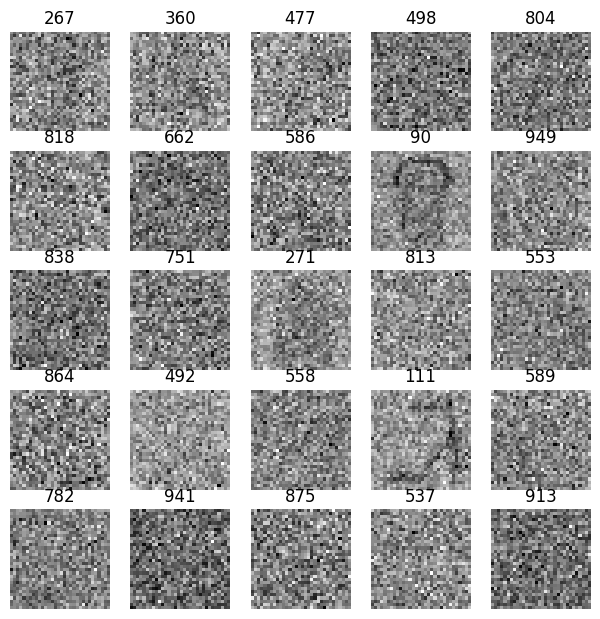

In [21]:
# Display the noisy images with their timesteps as titles
# fc.map_ex converts each timestep number to a string
titles = fc.map_ex(t, '{}')  # Format each t as string
show_images(xt, imsize=1.5, titles=titles)

**What you should see:**

25 images with varying amounts of noise:
- Low timesteps (0-200): Image is clearly visible
- Medium timesteps (300-700): Image is partially visible through noise
- High timesteps (800-999): Almost pure noise, image barely visible

### 🎮 Interactive (3D): a whole dataset melting into a Gaussian

You just saw 25 individual images at different noise levels. Now zoom out: what does diffusion do to the **entire data distribution**? Images live in 1024-dimensional space, so here is the same process on a 2-D dataset you can actually see, with **time as the third axis** (rendered with three.js):

**What to try**
- **Drag to orbit, scroll to zoom.** Look down the time axis from the noisy end — the structured cloud becomes a perfectly round Gaussian ball.
- Press ▶ and watch the sweep plane travel; then flip **direction: reverse** to see it as sampling would run.
- Toggle **trajectories** on: every point travels a straight line from its data position to its own noise target ε — that's the closed-form x_t = √ᾱ_t·x₀ + √(1−ᾱ_t)·ε made visible.
- Switch datasets (two moons / spiral / blobs): no matter the starting shape, the destination is the **same** isotropic Gaussian — which is precisely why sampling can begin with `torch.randn`.

In [22]:
# ============================================================================
# INTERACTIVE (3D, three.js) -- run this cell. It loads
# ./interactive_viz/ddpm_diffusion_3d.html at full width (setup cell required).
# Drag to orbit, scroll to zoom.
# ============================================================================
show_viz("interactive_viz/ddpm_diffusion_3d.html", height="720px")

---

## Section 5: Training Setup

Now let's set up the model and training loop.

In [23]:
# Import the U-Net model from HuggingFace diffusers
from diffusers import UNet2DModel

### The Sampling Function

This function generates new images by starting from pure noise and iteratively denoising.

In [24]:
@torch.no_grad()  # Disable gradient computation for inference
def sample(model, sz, alpha, alphabar, sigma, n_steps):
    """
    Generate images by reversing the diffusion process.

    Starting from pure noise, iteratively predict and remove noise
    until we get clean images.

    Parameters:
    -----------
    model : nn.Module
        The trained U-Net that predicts noise
    sz : tuple
        Shape of images to generate, e.g., (16, 1, 32, 32)
    alpha, alphabar, sigma : torch.Tensor
        The noise schedule parameters
    n_steps : int
        Number of diffusion steps

    Returns:
    --------
    list of torch.Tensor
        Images at each timestep (for visualization)
    """
    device = next(model.parameters()).device

    # Start with pure random noise (x_T)
    x_t = torch.randn(sz, device=device)

    # Store predictions at each step for visualization
    preds = []

    # Iterate backwards through timesteps: T-1, T-2, ..., 1, 0
    for t in reversed(range(n_steps)):
        # Create a batch of the current timestep
        # Create a batch of the same timestep for all images
        # Shape: (batch_size,) all filled with value t
        t_batch = torch.full((x_t.shape[0],), t, device=device, dtype=torch.long)

        # Random noise z (zero for the final step)
        z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(device)

        # Get alphabar for timestep t-1 (or 1 if t=0)
        alphabar_t1 = alphabar[t-1] if t > 0 else torch.tensor(1)

        # Noise variances
        b_bar_t = 1 - alphabar[t]      # Noise variance at t
        b_bar_t1 = 1 - alphabar_t1     # Noise variance at t-1

        # Predict the noise using the model
        noise_pred = learn.model((x_t, t_batch))

        # Estimate x_0 (the clean image) from our current x_t and predicted noise
        # Rearranging: x_t = sqrt(alphabar_t)*x_0 + sqrt(1-alphabar_t)*eps
        # Gives: x_0 = (x_t - sqrt(1-alphabar_t)*eps) / sqrt(alphabar_t)
        x_0_hat = ((x_t - b_bar_t.sqrt() * noise_pred) / alphabar[t].sqrt()).clamp(-1, 1)

        # Compute x_{t-1} using the DDPM update formula
        x_t = (x_0_hat * alphabar_t1.sqrt() * (1 - alpha[t]) / b_bar_t +
               x_t * alpha[t].sqrt() * b_bar_t1 / b_bar_t +
               sigma[t] * z)

        # Save for visualization
        preds.append(x_t.cpu())

    return preds

**What does the code above do?**

Implements the reverse diffusion process (DDPM sampling):

```
Pure Noise (x_T) ──► x_{T-1} ──► x_{T-2} ──► ... ──► x_1 ──► Clean Image (x_0)
                        │           │                   │
                        ▼           ▼                   ▼
                   Model predicts noise and we remove it at each step
```

**The key steps:**
1. Start with random noise
2. For each timestep (going backwards):
   - Predict the noise using our model
   - Estimate what the clean image might be
   - Take one step towards the clean image
3. After 1000 steps, we have a generated image!

### 🔄 Compared with notebook 15: `sample` as a function vs. a method

In notebook 15, `sample` is a **method on `DDPMCB`** that reads the schedule from `self`:

```python
# notebook 15 (signature):
class DDPMCB(TrainCB):
    ...
    def sample(self, model, sz):
        # uses self.ᾱ, self.α, self.σ, self.n_steps internally
```

and is invoked through the callback instance: `samples = ddpm_cb.sample(learn.model, (16, 1, 32, 32))`.

Here it's a **standalone function with explicit arguments**: `sample(model, sz, alpha, alphabar, sigma, n_steps)`, decorated with `@torch.no_grad()`.

**What's the same:** the loop itself — iterate `t = T−1 … 0`, build `t_batch`, draw `z` (zero at the final step), predict ε̂, form the implied x̂₀, take the weighted DDPM step. The generated images are statistically identical.

**What's different, and why it matters:**
- **Explicit dependencies.** The function signature *is* the documentation: sampling needs a model, a shape, and four schedule tensors — nothing else. In the method version those dependencies are invisible until you read the body.
- **Usable without training machinery.** You can load a saved model in a fresh session and call `sample(...)` with schedule tensors from Section 3 — no callback, no Learner. In notebook 15 you must construct a `DDPMCB(1000, 0.0001, 0.02)` first just to borrow its method (and its `self.ᾱ`).
- **`@torch.no_grad()` at the definition** makes inference-mode a property of the function rather than something the caller must remember.
- The thin `DDPMCB` in this notebook still exposes `.sample(model, sz)` for convenience — but it's a two-line delegation to this function, not a second implementation.

### 🎮 Interactive: the sampling walk — scrub the reverse process

The `sample` function above is a loop of four moves repeated ~1000 times. Here you can **stand inside the loop**:

**What to try**
- **Click anywhere on the timeline** to jump to that step (the strip behind it shows the actual trajectory). Press **▶ Denoise** and adjust the speed.
- Walk the stage chips — **① z ② predict ε̂ ③ implied x̂₀ ④ blend** — each highlights the matching line of `sample`.
- Park at t≈180 and stare at the **x̂₀ panel**: a gray ghost. Now scrub to t≈40: details have crystallized. This is why one giant jump can't work and ~1000 small steps can.
- Check the live **weights panel** in stage ④: early on, x_{t−1} mostly keeps x_t (cautious steps); near t=0 it mostly trusts x̂₀. And at the very last step, σ·z is forced to 0 — find out why in the ① chip.

In [25]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm_sampling_walk.html
# at full width, sized to fit the visualization (setup cell near the top required).
# ============================================================================
show_viz("interactive_viz/ddpm_sampling_walk.html", height="880px")

### The DDPM Callback

This callback handles adding noise to batches during training.

In [26]:
class DDPMCB(Callback):
    """
    DDPM Training Callback.

    Handles:
    1. Computing the noise schedule
    2. Noisifying batches during training
    3. Sampling after training
    """
    order = DeviceCB.order + 1  # Run after DeviceCB

    def __init__(self, n_steps, beta_min, beta_max):
        """
        Parameters:
        -----------
        n_steps : int
            Number of diffusion steps (typically 1000)
        beta_min : float
            Minimum noise variance
        beta_max : float
            Maximum noise variance
        """
        super().__init__()
        fc.store_attr()  # Store all args as self.xxx

        # Compute the noise schedule
        self.beta = torch.linspace(self.beta_min, self.beta_max, self.n_steps)
        self.alpha = 1. - self.beta
        self.alphabar = torch.cumprod(self.alpha, dim=0)
        self.sigma = self.beta.sqrt()

    def before_batch(self, learn):
        """
        Called before each batch.
        Replace the batch with (noisy_images, noise) pairs.
        """
        # learn.batch[0] is the images (we ignore labels)
        # noisify returns ((noisy_img, timestep), noise)
        learn.batch = noisify(learn.batch[0], self.alphabar)

    def sample(self, model, sz):
        """
        Generate samples using the trained model.
        """
        return sample(model, sz, self.alpha, self.alphabar, self.sigma, self.n_steps)

**What does the code above do?**

Creates a callback that:

1. **`__init__`**: Computes the noise schedule (beta, alpha, alphabar, sigma)

2. **`before_batch`**: Transforms each batch:
   - Input: `(images, labels)` from the DataLoader
   - Output: `((noisy_images, timesteps), noise)` for training

3. **`sample`**: Wrapper around the sample function for generating images

### 🔄 Compared with notebook 15: thin callback vs. monolithic callback

This is the **single biggest structural difference** between the two notebooks. Notebook 15's `DDPMCB` is the whole show:

```python
# notebook 15:
class DDPMCB(TrainCB):                      # ← subclasses TrainCB
    order = DeviceCB.order + 1
    def __init__(self, n_steps, beta_min, beta_max):
        super().__init__()
        self.n_steps, self.βmin, self.βmax = n_steps, beta_min, beta_max
        self.β = torch.linspace(...); self.α = 1. - self.β
        self.ᾱ = torch.cumprod(self.α, dim=0); self.σ = self.β.sqrt()
    def predict(self, learn):
        learn.preds = learn.model(*learn.batch[0]).sample   # ← unpack + .sample here
    def before_batch(self, learn):
        ...40 lines of inline noisify...
    def sample(self, model, sz):
        ...the whole reverse loop...
```

One class holds **four jobs**: schedule construction, forward noising, adapting the model's calling convention, and generation.

This notebook's version keeps only the *glue*:

```python
# this notebook:
class DDPMCB(Callback):                     # ← plain Callback, not TrainCB
    order = DeviceCB.order + 1
    def __init__(self, n_steps, beta_min, beta_max):
        super().__init__()
        fc.store_attr()                     # ← stores all args as self.xxx in one line
        self.beta = torch.linspace(...); ...
    def before_batch(self, learn):
        learn.batch = noisify(learn.batch[0], self.alphabar)   # ← one line, delegates
```

**Why the differences line up the way they do:**
- **`Callback` vs `TrainCB`:** notebook 15 *had* to subclass `TrainCB` because it needed to override `predict` (to unpack the tuple and grab `.sample`). Here that quirk is absorbed by the `UNet` wrapper in the next cell — so nothing about prediction needs customizing, and a plain `Callback` suffices while `TrainLearner` provides the standard training methods.
- **`fc.store_attr()`** replaces three manual `self.x = x` assignments — a small fastcore idiom worth knowing.
- **Where did `sample` and `noisify` go?** Nowhere — they became the module-level functions you already read. The callback shrank because its jobs were given proper homes, not because work was deleted.
- **What's the same:** `order = DeviceCB.order + 1` (must run after data reaches the GPU), the constructor signature, and the schedule recipe inside `__init__`.

### UNet Wrapper

The diffusers UNet2DModel expects two separate arguments (image, timestep), but our training loop passes them as a tuple. This wrapper handles that.

In [27]:
class UNet(UNet2DModel):
    """
    Wrapper around UNet2DModel that:
    1. Accepts input as a tuple (image, timestep)
    2. Extracts just the sample from the output
    """
    def forward(self, x):
        # x is a tuple: (noisy_image, timestep)
        # *x unpacks it to two separate arguments
        # .sample extracts the actual output tensor
        return super().forward(*x).sample

# Why This UNet Wrapper Exists

## The Core Problem: Interface Mismatch

Two different APIs need to work together, but they speak different languages.

**`UNet2DModel.forward()`** (HuggingFace Diffusers) expects **two separate arguments**:

```python
unet(noisy_image, timestep)  # two args
```

And returns a **dataclass object** `UNet2DOutput`, not a plain tensor:

```python
output.sample  # you must extract the tensor like this
```

**The sampling loop** calling the UNet expects a **callable that takes a single tuple** and **returns a plain tensor**:

```python
model((noisy_image, timestep))  # one arg: a tuple
# and expects back a raw tensor, not a dataclass
```

---

## What the Wrapper Does — Line by Line

```python
def forward(self, x):           # x arrives as ONE thing: a tuple (image, timestep)
    return super().forward(*x)  # *x unpacks tuple → two separate args, as UNet2DModel expects
                   .sample      # extract tensor from UNet2DOutput dataclass
```

| Problem | Solution |
|---|---|
| Caller passes `(image, timestep)` as a **single tuple** | `self, x` accepts it as one argument |
| Parent `forward()` needs **two separate args** | `*x` unpacks the tuple |
| Parent returns `UNet2DOutput` **dataclass** | `.sample` extracts the raw tensor |

---

## The Deeper "Why": Adapter Pattern

This pattern appears because the UNet is passed into a **generic DDPM sampler loop** that treats the model as a black-box function:

```python
# The sampler just does something like:
predicted_noise = model((x_t, t))  # expects: tuple in, tensor out
```

Rather than rewriting the sampling loop, the wrapper **adapts the UNet's interface** to match what the loop expects — a classic **Adapter Pattern**. The UNet's complex API is hidden behind a simpler `(tuple) → tensor` contract.

**What does the code above do?**

The original UNet2DModel's forward method:
```python
output = model(image, timestep)  # Two separate arguments
noise_pred = output.sample       # Need to extract .sample
```

Our wrapper simplifies this:
```python
noise_pred = model((image, timestep))  # Single tuple argument, returns tensor directly
```

### 🔄 Compared with notebook 15: wrapper class vs. `predict` override

Both notebooks face the same two-part interface mismatch: the batch carries `(xt, t)` as one object while `UNet2DModel.forward` wants two arguments, and diffusers returns an output *object* whose tensor hides behind `.sample`. They patch it in different places:

```python
# notebook 15 — patched in the CALLBACK:
def predict(self, learn):
    learn.preds = learn.model(*learn.batch[0]).sample
```

```python
# this notebook — patched in the MODEL:
class UNet(UNet2DModel):
    def forward(self, x): return super().forward(*x).sample
```

**Why the model-side patch is the nicer home:**
- The quirk belongs to the model (diffusers' API), so fixing it *at the model* means everything downstream — `TrainLearner`, loss computation, even `sample()` — can treat it as an ordinary `nn.Module`: tensor in, tensor out.
- It's why this notebook's callback could drop the `predict` override entirely and stop being a `TrainCB`.
- The wrapped model is also pleasant interactively: `model((xt, t))` works in any cell.

**Trade-off, honestly stated:** the wrapper hides the tuple-unpacking magic inside the class, and Section 8 has to *undo* it — Accelerate prefers flat batches, so there the raw `UNet2DModel` returns along with a tiny `DDPMCB2.after_predict` that re-extracts `.sample` (notebook 15's approach, essentially, relocated to `after_predict`). Neither placement is universally right; this notebook simply picks the one that keeps the *default* path cleanest.

In [28]:
# Create the DDPM callback with standard parameters
ddpm_cb = DDPMCB(n_steps=1000, beta_min=0.0001, beta_max=0.02)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


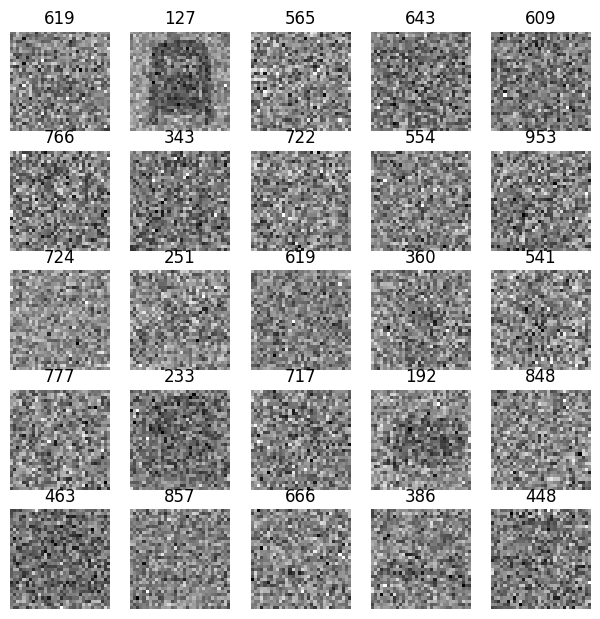

In [29]:
# Test that everything works with a single batch

# Create a small model for testing
model = UNet(
    in_channels=1,           # Grayscale images (1 channel)
    out_channels=1,          # Output is also 1 channel (noise prediction)
    block_out_channels=(16, 32, 64, 64),  # Channels at each level
    norm_num_groups=8        # Groups for GroupNorm
)

# Create learner and run one batch (train=False means no actual training)
learn = TrainLearner(model, dls, nn.MSELoss())
learn.fit(train=False, cbs=[ddpm_cb, SingleBatchCB()])

# Extract the batch that was created
(xt, t), epsilon = learn.batch

# Display the noisy images with timesteps
show_images(xt[:25], titles=fc.map_ex(t[:25], '{}'), imsize=1.5)

**What does the code above do?**

Tests our setup by:
1. Creating a model
2. Running through one batch with the DDPM callback
3. Displaying the resulting noisy images

This verifies that the noisification is working correctly.

# Understanding `train=False` and Callback Execution in DDPM

This document explains why we use `learn.fit(train=False, ...)` and how callbacks still execute even when training is disabled.

## What `train=False` Does

When you call `learn.fit(train=False, ...)`, you're telling the learner to run through the training pipeline **without actually computing gradients or updating weights**. However, the callbacks still execute in their normal order.

Think of it as a "dry run" through the training machinery.

## The Callback Execution Flow

Even with `train=False`, the callback lifecycle still happens:

```
fit() called
    │
    ├── before_fit callbacks run
    │
    ├── for each epoch:
    │       │
    │       ├── before_epoch callbacks run
    │       │
    │       ├── for each batch:
    │       │       │
    │       │       ├── before_batch callbacks run  ← DDPMCB.before_batch() executes here!
    │       │       │
    │       │       ├── (forward pass - skipped or minimal with train=False)
    │       │       │
    │       │       └── after_batch callbacks run   ← SingleBatchCB stops here!
    │       │
    │       └── after_epoch callbacks run
    │
    └── after_fit callbacks run
```

## How Each Callback Contributes

**`DDPMCB.before_batch()`** transforms the clean images into noisy training data:

```python
def before_batch(self, learn):
    learn.batch = noisify(learn.batch[0], self.ᾱ)
    # Input:  learn.batch = (clean_images, labels)
    # Output: learn.batch = ((noisy_images, timesteps), noise)
```

**`SingleBatchCB`** stops training after just one batch:

```python
class SingleBatchCB(Callback):
    def after_batch(self, learn):
        raise CancelFitException  # Stops the entire fit loop
```

## Why This Pattern is Useful

This approach lets you **inspect the data pipeline** without waiting for actual training:

| Purpose | What You Can Verify |
|---------|---------------------|
| Debug data flow | Does `noisify()` produce correct shapes? |
| Visualize preprocessing | What do noisy images look like at different timesteps? |
| Test model compatibility | Can the model accept the transformed batch? |
| Check device placement | Are tensors on the correct device (CPU/GPU)? |

## What the Code Accomplishes

```python
learn.fit(train=False, cbs=[ddpm_cb, SingleBatchCB()])
(xt, t), epsilon = learn.batch
show_images(xt[:25], titles=fc.map_ex(t[:25], '{}'), imsize=1.5)
```

After this runs:
- `xt` contains 25 noisy images at various noise levels
- `t` contains the timestep for each image (0-999)
- `epsilon` contains the actual noise that was added
- The visualization shows you what the diffusion forward process looks like

This is essentially a **sanity check** before committing to a full training run. You can verify that images at low timesteps (t≈0) look almost clean, while images at high timesteps (t≈999) look like pure noise.

## The Key Insight

The callback system decouples data transformation from training. `DDPMCB` doesn't care whether gradients are being computed—it just transforms batches. This modularity means you can test, debug, and visualize your pipeline independently from the optimization process.

## Code Reference

```python
# Test that everything works with a single batch

# Create a small model for testing
model = UNet(
    in_channels=1,           # Grayscale images (1 channel)
    out_channels=1,          # Output is also 1 channel (noise prediction)
    block_out_channels=(16, 32, 64, 64),  # Channels at each level
    norm_num_groups=8        # Groups for GroupNorm
)

# Create learner and run one batch (train=False means no actual training)
learn = TrainLearner(model, dls, nn.MSELoss())
learn.fit(train=False, cbs=[ddpm_cb, SingleBatchCB()])

# Extract the batch that was created
(xt, t), epsilon = learn.batch

# Display the noisy images with timesteps
show_images(xt[:25], titles=fc.map_ex(t[:25], '{}'), imsize=1.5)
```

### Training Parameters and Initialization

In [30]:
# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================

lr = 5e-3      # Learning rate
epochs = 5     # Number of epochs

# Total training steps for learning rate scheduler
tmax = epochs * len(dls.train)

# OneCycleLR scheduler: warmup -> max -> cooldown
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)

# Callbacks for training
cbs = [
    ddpm_cb,                    # DDPM noise handling
    DeviceCB(),                 # Move to GPU
    ProgressCB(plot=True),      # Progress bar and loss plot
    MetricsCB(),                # Track metrics
    BatchSchedCB(sched)         # Learning rate schedule
]

In [31]:
# Create the model with larger capacity
# Note: (16, 32, 64, 128) vs (16, 32, 64, 64) - last level has more channels
model = UNet(
    in_channels=1,
    out_channels=1,
    block_out_channels=(16, 32, 64, 128),  # More channels = more capacity
    norm_num_groups=8
)

### 🔄 Compared with notebook 15: the model and hyperparameters

```python
# notebook 15:
model = UNet2DModel(in_channels=1, out_channels=1,
                    block_out_channels=(32, 64, 128, 128))   # norm_num_groups: default (32)
lr = 4e-3
```

```python
# this notebook:
model = UNet(in_channels=1, out_channels=1,
             block_out_channels=(16, 32, 64, 128), norm_num_groups=8)
lr = 5e-3
```

**Differences worth noticing:**
- **Leaner early layers:** `(16, 32, …)` vs `(32, 64, …)` — high-resolution levels are the expensive ones (channels × 32×32 positions), so halving them cuts compute where it hurts most, while the deepest level keeps 128 channels for capacity.
- **`norm_num_groups=8` is forced by that choice:** diffusers defaults to 32 groups, which works for notebook 15's 32-channel first block but would crash on a 16-channel block (16 is not divisible by 32). Every entry in `(16, 32, 64, 128)` is a multiple of 8 — see the GroupNorm explainer and 🎮 explorer above.
- **Slightly higher lr** (`5e-3` vs `4e-3`), and later `1e-2` once mixed precision + bs=512 arrive — larger batches support larger learning rates.
- **What's the same:** epochs=5 (for this first run), OneCycleLR via `BatchSchedCB(partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax))`, `nn.MSELoss()`, Adam, and the callback list structure (`DeviceCB`, `ProgressCB(plot=True)`, `MetricsCB`, scheduler CB) — that whole recipe carried over intact.

# Understanding `norm_num_groups=8` in UNet for Diffusion Models

The `norm_num_groups=8` parameter controls **Group Normalization**, a normalization technique used inside the UNet architecture. Let me explain why it's needed and how it works.

## What is Group Normalization?

Group Normalization divides channels into groups and normalizes within each group independently. It's an alternative to Batch Normalization that works better with small batch sizes—common in diffusion models where images are large and GPU memory is limited.

```
Channels: [c1, c2, c3, c4, c5, c6, c7, c8, c9, c10, c11, c12, c13, c14, c15, c16]
           |______Group 1______|  |______Group 2______|  |_______..._________|
           
With norm_num_groups=8 and 16 channels → 2 channels per group
```

## Why `norm_num_groups=8` Specifically?

The key constraint is that **the number of channels must be divisible by the number of groups**. Looking at your `block_out_channels=(16, 32, 64, 128)`:

| Block Level | Channels | Groups | Channels per Group | Valid? |
|-------------|----------|--------|-------------------|--------|
| Level 0 | 16 | 8 | 2 | ✓ |
| Level 1 | 32 | 8 | 4 | ✓ |
| Level 2 | 64 | 8 | 8 | ✓ |
| Level 3 | 128 | 8 | 16 | ✓ |

With 8 groups, all channel counts divide evenly. If you tried `norm_num_groups=32`, level 0 would fail (16 ÷ 32 is not a whole number).

## Why Not Batch Normalization?

Batch Normalization computes statistics across the batch dimension, which becomes unstable when batch sizes are small:

```
Batch Norm: normalizes across batch → needs large batches (32+)
Group Norm: normalizes across channel groups → batch-size independent
```

Diffusion models typically use batch sizes of 4-16 due to memory constraints, making Group Normalization the preferred choice.

## The Trade-off in Choosing Group Count

Fewer groups (e.g., 4) means more channels normalized together, capturing broader feature interactions but potentially mixing unrelated features. More groups (e.g., 16 or 32) means finer-grained normalization but requires enough channels at every layer. The value 8 is a practical default that balances these concerns while remaining compatible with common channel configurations like powers of 2.

## Code Reference

```python
# Create the model with larger capacity
model = UNet(
    in_channels=1,
    out_channels=1,
    block_out_channels=(16, 32, 64, 128),  # More channels = more capacity
    norm_num_groups=8  # Group Normalization with 8 groups
)
```

# How Group Normalization Works

## The Problem It Solves

Before normalization, activations inside a neural network can grow very large or very small as they pass through layers — making training unstable. We need to **normalize** them back to a manageable range.

---

## The Core Idea

Group Normalization divides the **channels** of a layer into groups, then normalizes within each group independently.

```
norm_num_groups=8 means: split channels into groups of 8
```

For a model with `block_out_channels=(16, 32, 64, 128)`:

| Level | Channels | Groups | Channels per Group |
|---|---|---|---|
| Level 1 | 16 | 8 | 2 |
| Level 2 | 32 | 8 | 4 |
| Level 3 | 64 | 8 | 8 |
| Level 4 | 128 | 8 | 16 |

---

## What "Normalizing a Group" Actually Means

For each group, it computes the mean and variance **across the spatial dimensions (H, W) and the channels within that group**, then rescales:

```
x_normalized = (x - mean) / sqrt(variance + ε)
output = γ * x_normalized + β
```

- `γ` (gamma) and `β` (beta) are **learnable** — the network can undo the normalization if needed
- `ε` is a tiny number to avoid division by zero

---

## Why Not Batch Norm?

This is the key reason diffusion models use GroupNorm:

```
Batch Norm  → normalizes across the BATCH dimension
Group Norm  → normalizes across CHANNEL GROUPS
```

Diffusion models often run with **small batch sizes** (or batch size 1 at inference). Batch Norm's statistics become unreliable with small batches. Group Norm has **no dependency on batch size** — it works identically during training and inference.

---

## Visual Intuition

```
Feature map shape: [Batch, Channels, Height, Width]

Batch Norm:   normalize across ← B dimension, per channel
Layer Norm:   normalize across        C, H, W → per sample
Group Norm:   normalize across     group of C, H, W → per group per sample
```

Group Norm sits between Layer Norm and Instance Norm — it keeps some channel structure while staying batch-independent. That's why it's the standard choice for UNets in diffusion models.

### 🎮 Interactive: GroupNorm explorer — who shares statistics with whom?

`norm_num_groups=8` is a single argument hiding a whole design decision. Every norm layer computes `(x − μ)/σ` — the only question is **which activations are pooled** to get μ and σ:

**What to try**
- **Click any cell** of the (N=4, C=16) tensor, then switch between **BatchNorm / LayerNorm / InstanceNorm / GroupNorm** — teal shows everything pooled with your cell.
- On GroupNorm, slide **num_groups to 1 and then to 16**: you'll literally watch it morph into LayerNorm and InstanceNorm — GroupNorm contains both as special cases.
- Slide to **3 groups** and read the ⚠️: 16 isn't divisible by 3 — this is exactly why every entry of `block_out_channels=(16, 32, 64, 128)` is a multiple of 8.
- Notice that for every mode *except* BatchNorm, the teal never crosses rows — statistics never depend on your batchmates. In diffusion, where each image sits at a different noise level t, that batch-independence is essential.

In [32]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/groupnorm_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# ============================================================================
show_viz("interactive_viz/groupnorm_explorer.html", height="780px")

### Custom Weight Initialization

Good initialization is crucial for training. We'll zero out certain layers so the model starts by predicting "no change".

In [33]:
def init_ddpm(model):
    """
    Initialize DDPM model weights for better training.

    Key ideas:
    1. Zero out the final conv in each residual block
       -> Model starts by outputting zero (predicting no noise)
    2. Orthogonal init for downsampling convolutions
       -> Preserves gradient magnitude during downsampling
    3. Zero out the final output convolution
       -> Clean starting point
    """
    # Initialize down blocks
    for o in model.down_blocks:
        # Zero the second conv in each ResNet block. By zeroing the final layer of the
        # residual branch, the block initially acts as an identity mapping, which
        # significantly improves training stability by allowing gradients to flow
        # unimpeded through the skip connections.
        for p in o.resnets:
            p.conv2.weight.data.zero_()
        # Downsamplers are layers (typically strided convolutions) that reduce the
        # spatial resolution of the feature maps. Orthogonal initialization is used
        # here to preserve the variance of the signal and the magnitude of gradients
        # as they pass through different scales, ensuring stable training.
        for p in fc.L(o.downsamplers):
            nn.init.orthogonal_(p.conv.weight)

    # Initialize up blocks
    for o in model.up_blocks:
        # Zero the second conv in each ResNet block
        for p in o.resnets:
            p.conv2.weight.data.zero_()

    # Zero the final output convolution
    model.conv_out.weight.data.zero_() # start by predicting zero

**What does the code above do?**

Initializes the model weights for stable training:

**Why zero out residual block outputs?**

In a residual block: `output = input + f(input)`

If `f(input) = 0` at initialization, then `output = input` (identity function).

This means:
- The model starts by doing nothing
- Gradients flow easily (identity has gradient = 1)
- Training is more stable

**Why orthogonal initialization for downsampling?**

Orthogonal matrices preserve vector norms. This helps gradients flow without exploding or vanishing.

# Understanding `fc.L(o.downsamplers)` in DDPM Initialization

This explains what `fc.L()` does and why it's needed when initializing UNet weights for diffusion models.

## What is `fc.L()`?

`fc.L()` is a fastcore utility that creates a "smart list" called an `L` object. Its key feature is that it **safely handles `None` values** by converting them to empty lists.

```python
import fastcore.all as fc

fc.L([1, 2, 3])    # Returns: L([1, 2, 3])
fc.L(None)         # Returns: L([])  ← This is the key behavior!
fc.L("hello")      # Returns: L(['hello'])
```

## Why It's Needed for `o.downsamplers`

In a UNet architecture, **not every block has a downsampler**. Specifically:

| Block Position | Has Downsampler? | `o.downsamplers` value |
|----------------|------------------|------------------------|
| Down block 0 | Yes | `[Conv2d(...)]` |
| Down block 1 | Yes | `[Conv2d(...)]` |
| Down block 2 | Yes | `[Conv2d(...)]` |
| Down block 3 (bottom) | **No** | `None` |

The bottom block doesn't downsample because you've reached the lowest resolution—there's nowhere else to go down.

## The Problem Without `fc.L()`

```python
# This would crash on the bottom block!
for o in model.down_blocks:
    for p in o.downsamplers:  # TypeError: 'NoneType' is not iterable
        nn.init.orthogonal_(p.conv.weight)
```

## The Solution With `fc.L()`

```python
# This works safely for all blocks
for o in model.down_blocks:
    for p in fc.L(o.downsamplers):  # None becomes empty list, loop just skips
        nn.init.orthogonal_(p.conv.weight)
```

## What We're Looping Through

When `o.downsamplers` is not `None`, it contains downsampling layers—typically strided convolutions that reduce spatial dimensions by half:

```
Input: 64×64 → Downsampler → Output: 32×32
Input: 32×32 → Downsampler → Output: 16×16
Input: 16×16 → Downsampler → Output: 8×8
Input: 8×8   → (no downsampler at bottom)
```

Each downsampler `p` has a `conv` attribute containing the actual convolution layer, and we initialize its weights with orthogonal initialization to preserve gradient magnitude across scales.

## Visual Summary

```
model.down_blocks:
    │
    ├── down_block[0]
    │       ├── resnets: [ResNet, ResNet]     ← zero conv2 weights
    │       └── downsamplers: [Downsample2D]  ← orthogonal init
    │
    ├── down_block[1]
    │       ├── resnets: [ResNet, ResNet]     ← zero conv2 weights
    │       └── downsamplers: [Downsample2D]  ← orthogonal init
    │
    ├── down_block[2]
    │       ├── resnets: [ResNet, ResNet]     ← zero conv2 weights
    │       └── downsamplers: [Downsample2D]  ← orthogonal init
    │
    └── down_block[3] (bottom)
            ├── resnets: [ResNet, ResNet]     ← zero conv2 weights
            └── downsamplers: None            ← fc.L() makes this safe to skip
```

The `fc.L()` wrapper is a defensive programming pattern that makes the code robust to architectural variations where some blocks may lack certain components.

## Code Reference

```python
def init_ddpm(model):
    """
    Initialize DDPM model weights for better training.
    """
    # Initialize down blocks
    for o in model.down_blocks:
        # Zero the second conv in each ResNet block
        for p in o.resnets:
            p.conv2.weight.data.zero_()
        # Downsamplers - fc.L() handles None safely
        for p in fc.L(o.downsamplers):
            nn.init.orthogonal_(p.conv.weight)

    # Initialize up blocks
    for o in model.up_blocks:
        for p in o.resnets:
            p.conv2.weight.data.zero_()

    # Zero the final output convolution
    model.conv_out.weight.data.zero_()
```

In [34]:
# Apply the initialization
init_ddpm(model)

### 🔄 Compared with notebook 15: initialization — new here entirely

Notebook 15 **has no custom initialization**: the model trains from diffusers' default weights. `init_ddpm` is one of this notebook's genuinely new ingredients, not a reorganization:

- zeroing `conv2` in every residual block makes each block start as an **identity mapping** (output = skip connection), so early training flows gradients cleanly through the whole depth;
- zeroing the final output conv means the untrained model predicts **zero noise** — a sane, unbiased starting guess for a network whose job is ε-prediction;
- orthogonal init on downsamplers preserves signal/gradient scale across resolution changes.

Together with the leaner architecture, this is part of why this notebook can push the learning rate higher than notebook 15's `4e-3` without diverging. If you ever wonder "would notebook 15 train fine with this init added?" — yes, and it's a nice exercise: `init_ddpm` works on any `UNet2DModel`.

In [35]:
# Custom optimizer with small epsilon for numerical stability
# eps=1e-5 (instead of default 1e-8) helps with mixed precision training
opt_func = partial(optim.Adam, eps=1e-5)

In [36]:
# Create the learner with all components
learn = TrainLearner(
    model,           # Our initialized UNet
    dls,             # DataLoaders
    nn.MSELoss(),    # Mean Squared Error loss
    lr=lr,           # Learning rate
    cbs=cbs,         # Callbacks
    opt_func=opt_func  # Adam optimizer
)

### 🔄 Compared with notebook 15: `TrainLearner` vs `Learner` + `TrainCB`

```python
# notebook 15:
learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=optim.Adam)
# ...where cbs includes ddpm_cb, a TrainCB subclass that supplies
# predict / get_loss / backward / step / zero_grad
```

```python
# this notebook:
learn = TrainLearner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=opt_func)
# ...training methods are built into the Learner; ddpm_cb is a plain Callback
```

Same miniai machinery, opposite ends of it: in notebook 15 the *callback* provides the five training methods (because it needed to customize `predict` anyway); here nothing needs customizing (the `UNet` wrapper saw to that), so the batteries-included `TrainLearner` is used and the callback stays minimal. Also new here: `opt_func = partial(optim.Adam, eps=1e-5)` — the larger epsilon guards against division-by-tiny-values instability, which matters more once mixed precision enters in Section 7 (notebook 15 uses plain `optim.Adam`).

loss,epoch,train
0.148,0,train
0.025,0,eval
0.023,1,train
0.021,1,eval
0.020,2,train
0.021,2,eval
0.019,3,train
0.018,3,eval
0.018,4,train
0.018,4,eval


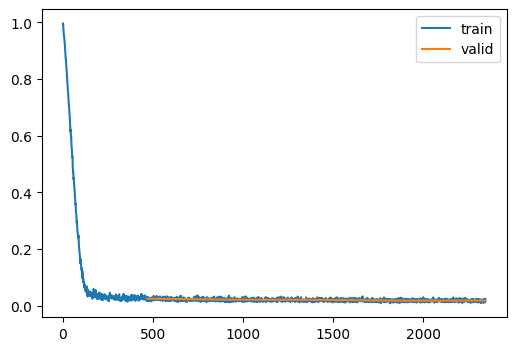

In [37]:
# Train the model!
learn.fit(epochs)

**What should you see?**

- Progress bar showing training progress
- Loss curve that decreases over time
- Training takes about 5-10 minutes on a GPU

In [38]:
# Create directory for saving models
mdl_path = Path('models')

In [39]:
# Save the trained model
torch.save(learn.model, mdl_path/'fashion_ddpm2.pkl')

In [41]:
# Load the model (useful if you restart the notebook)
learn.model = torch.load(mdl_path/'fashion_ddpm2.pkl', weights_only=False)

---

## Section 6: Sampling (Generating Images)

In [42]:
# Generate 16 images
# Shape: (16, 1, 32, 32) = 16 grayscale 32x32 images
samples = ddpm_cb.sample(learn.model, (16, 1, 32, 32))

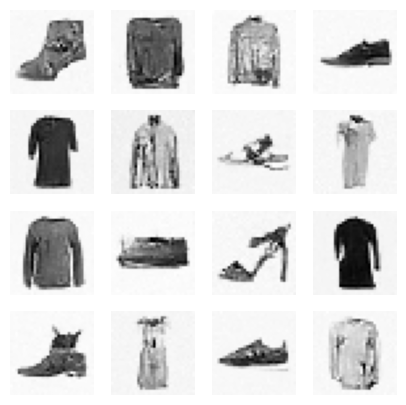

In [43]:
# Display the final generated images
# samples[-1] is the last step (fully denoised)
show_images(samples[-1], figsize=(5, 5))

**What you should see:**

16 generated Fashion MNIST images! They should look like clothing items (shirts, pants, shoes, etc.).

---

## Section 7: Mixed Precision Training

**Mixed Precision** uses FP16 (16-bit floating point) instead of FP32 (32-bit) for most computations. This is faster and uses less memory!

**Why it works:**
- Most operations don't need FP32 precision
- GPUs have dedicated FP16 hardware (Tensor Cores) that's 2-8x faster
- Half the memory = bigger batch sizes

### 🔄 Compared with notebook 15: everything from here on is new

Notebook 15 ends where Section 6 of this notebook ends: train, save, sample, animate, summary. **Sections 7–10 have no counterpart there at all.** This is the payoff of the refactoring you've been reading about:

- **Mixed precision (Section 7)** slots in as just another callback — possible cleanly because training behaviour was never welded into `DDPMCB`.
- **`collate_ddpm` (Section 7)** reuses the *module-level* `noisify` inside DataLoader workers — impossible in notebook 15, where the noising logic exists only inside `before_batch`, and moving it out would mean rewriting the callback.
- **Accelerate (Section 8)** swaps `MixedPrecision` for `AccelerateCB` and adjusts the batch layout with a small `noisify` variant — again, editing one small function, not untangling a monolith.
- **`MultDL` (Section 9)** and the **nbdev export (Section 10)** round out the "make it fast, make it reusable" arc.

If you want a concrete appreciation exercise: sketch how you'd add `num_workers`-parallel noising to notebook 15's `DDPMCB`. You'll find yourself extracting a `noisify` function — i.e., re-deriving this notebook.

### 🎮 Interactive: the mixed precision lab — bits, underflow, and GradScaler

Before reading the callback code below, build the intuition in three mini-labs:

**What to try**
- **Lab 1 (the bits):** click individual bits of an FP32 and FP16 number. Try the presets — especially **tiny gradient 2e−8**, which FP16 silently rounds to 0.0, and **huge activation 70 000**, which overflows to inf. The number line shows exactly how much narrower FP16's world is.
- **Lab 2 (underflow):** drag the gradient slider into the red zone, watch direct FP16 storage kill it, then rescue it with the **loss scale** slider. Push the scale too far and you'll overflow instead — the reason the scale must be dynamic.
- **Lab 3 (the training step):** press ▶ Play and follow the staged pipeline — each stage highlights the matching method of the `MixedPrecision` callback you're about to read. Watch the **dynamic loss scale** halve on overflow events and creep back up on clean streaks.

In [44]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/mixed_precision_lab.html
# at full width, sized to fit the visualization (setup cell near the top required).
# ============================================================================
show_viz("interactive_viz/mixed_precision_lab.html", height="760px")

In [45]:
# With mixed precision, we can use a bigger batch size!
# 512 instead of 128 (4x larger)
bs = 512

### Custom Collate Function

Instead of noisifying in a callback (which happens after data loading), we can noisify during data loading using a custom collate function. This is more efficient!

In [46]:
# Look at what a raw batch looks like from the dataset
next(iter(DataLoader(tds['train'], batch_size=2)))

{'image': tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]]]),
 'label': tensor([9, 0])}

**What does this show?**

A raw batch is a dictionary with 'image' and 'label' keys. We need to:
1. Extract just the images
2. Apply noisification
3. Return in the format our training loop expects

In [47]:
def collate_ddpm(b):
    """
    Custom collate function that noisifies during data loading.

    Parameters:
    -----------
    b : list
        List of individual samples from the dataset

    Returns:
    --------
    tuple: ((noisy_images, timesteps), noise)
    """
    # default_collate combines individual samples into a batch
    # Then we extract just the images (xl = 'image')
    # And apply noisification
    return noisify(default_collate(b)[xl], alphabar)


def dl_ddpm(ds):
    """
    Create a DataLoader with our custom collate function.

    Parameters:
    -----------
    ds : Dataset
        The dataset to load from

    Returns:
    --------
    DataLoader with DDPM-specific collation
    """
    return DataLoader(
        ds,
        batch_size=bs,              # Use the larger batch size
        collate_fn=collate_ddpm,    # Our custom collate function
        num_workers=4               # Parallel data loading
    )

**What does the code above do?**

Creates a more efficient data loading pipeline:

**Before (with callback):**
```
DataLoader → Batch (images, labels) → GPU → Callback noisifies
```

**After (with custom collate):**
```
DataLoader → Custom collate noisifies → Batch ready for training
```

Benefits:
- Noisification happens in parallel with GPU computation
- CPU workers do the noisification while GPU trains
- Better pipeline efficiency

# How `default_collate(b)[xl]` Works

## What is `b`?

`b` is a **list of individual samples** coming from the dataset. Each sample is a dictionary (from HuggingFace datasets) that looks like:

```python
# One sample from the dataset:
{
    "image": tensor([...]),   # shape: [1, 28, 28] — one grayscale image
    "label": 7                # an integer
}

# So b, a batch of 4 samples, looks like:
b = [
    {"image": tensor([...]), "label": 7},
    {"image": tensor([...]), "label": 2},
    {"image": tensor([...]), "label": 1},
    {"image": tensor([...]), "label": 9},
]
```

---

## What Does `default_collate(b)` Do?

`default_collate` is PyTorch's built-in batch assembler. It takes that list of individual dictionaries and **stacks them key-by-key** into a single batched dictionary:

```python
default_collate(b) == {
    "image": tensor([...]),       # shape: [4, 1, 28, 28] — 4 images stacked
    "label": tensor([7, 2, 1, 9]) # shape: [4] — 4 labels stacked
}
```

It essentially does this under the hood:

```python
{
    "image": torch.stack([b[0]["image"], b[1]["image"], b[2]["image"], b[3]["image"]]),
    "label": torch.tensor([b[0]["label"], b[1]["label"], b[2]["label"], b[3]["label"]])
}
```

So the transformation is:

```
Input:   list of N dicts,   each with keys → scalar/tensor values
Output:  one dict,          each key       → batched tensor of shape [N, ...]
```

---

## What Does `[xl]` Do?

Recall that `xl = 'image'`. So:

```python
default_collate(b)[xl]
# is exactly the same as:
default_collate(b)["image"]
```

This **extracts just the image tensor** from the batched dictionary, discarding the labels entirely:

```python
default_collate(b)["image"]
# shape: [4, 1, 28, 28]  ← a batch of 4 grayscale 28x28 images
```

We don't need the labels — DDPM is **unsupervised**. The model learns to denoise, not classify. The labels are irrelevant to the training objective.

---

## The Full Line, Step by Step

```python
return noisify(default_collate(b)[xl], alphabar)
```

| Step | Code | What happens |
|---|---|---|
| 1 | `default_collate(b)` | List of sample dicts → one batched dict |
| 2 | `[xl]` / `["image"]` | Extract image tensor of shape `[B, 1, 28, 28]` |
| 3 | `noisify(..., alphabar)` | Add noise + return `((noisy_images, timesteps), noise)` |

---

## Why Override `collate_fn` at All?

The default DataLoader pipeline is:

```
Dataset.__getitem__()  →  default_collate()  →  your training loop
```

By passing `collate_fn=collate_ddpm`, we insert noisification **inside the data loading pipeline**:

```
Dataset.__getitem__()  →  collate_ddpm()  →  your training loop
                               ↓
                       default_collate()   ← still happens, inside our fn
                       extract images
                       noisify()
```

This means noisification runs **in the DataLoader workers** (parallel, on CPU), not in the training loop. It keeps the training loop clean and offloads preprocessing work efficiently.

# What `num_workers=4` Does in a PyTorch DataLoader

`num_workers=4` means the DataLoader spawns **4 separate worker processes** to load and prepare batches in parallel, rather than doing it in the main training process.

Without it (or with `num_workers=0`), data loading happens sequentially in the main process: the GPU sits idle while the next batch is being loaded and collated. With 4 workers, while the GPU trains on the current batch, those worker processes are simultaneously fetching, collating, and noisifying upcoming batches in the background. This way, the next batch is typically ready by the time the GPU needs it, keeping the training pipeline saturated and reducing overall training time.

### 🎮 Interactive: the data pipeline — where should `noisify` live?

`collate_ddpm` computes *exactly the same math* as the `DDPMCB` callback did — so why bother? Because **where** code runs matters as much as **what** it computes:

**What to try**
- Start in **callback mode** and watch the GPU box flash red before every step: noisify runs *serially* on the main process while the GPU waits. Note the "GPU busy" percentage.
- Switch to **collate mode**: the orange noisify work jumps into the 4 worker lanes and overlaps with training. Compare throughput.
- Toggle **MultDL ×2** (you'll meet it properly in Section 9): the GPU now trains twice on each delivered batch, draining the queue more slowly — a cheap win when data loading, not compute, is the bottleneck.

In [48]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm_data_pipeline.html
# at full width, sized to fit the visualization (setup cell near the top required).
# ============================================================================
show_viz("interactive_viz/ddpm_data_pipeline.html", height="760px")

In [49]:
"""
xl,yl = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name)

@inplace
def transformi(b): b[xl] = [F.pad(TF.to_tensor(o), (2,2,2,2)) for o in b[xl]]

bs = 128
tds = dsd.with_transform(transformi)
"""

# Create new DataLoaders with our custom collate function
dls = DataLoaders(dl_ddpm(tds['train']), dl_ddpm(tds['test']))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


### Mixed Precision Callback

This callback handles the mixed precision training mechanics.

In [50]:
#|export
class MixedPrecision(TrainCB):
    """
    Callback for mixed precision (FP16) training.

    Key components:
    1. GradScaler: Scales loss to prevent FP16 underflow
    2. autocast: Context manager that runs ops in FP16 where safe
    """
    order = DeviceCB.order + 10  # Run after DeviceCB

    def before_fit(self, learn):
        """
        Create the gradient scaler before training starts.

        GradScaler handles the tricky parts of FP16:
        - Scales up loss before backward (prevents underflow)
        - Scales down gradients before optimizer step
        - Adjusts scale dynamically if overflow/underflow detected
        """
        self.scaler = torch.cuda.amp.GradScaler()

    def before_batch(self, learn):
        """
        Enter autocast context for the forward pass.

        autocast automatically:
        - Runs matrix multiplications in FP16 (fast!)
        - Keeps sensitive ops (like softmax, loss) in FP32
        """
        self.autocast = torch.autocast("cuda", dtype=torch.float16)
        self.autocast.__enter__()

    def after_loss(self, learn):
        """
        Exit autocast context after loss is computed.
        """
        # Exit autocast context. __exit__ requires (type, value, traceback)
        # which are all None as we are not handling an exception here.
        self.autocast.__exit__(None, None, None)

    def backward(self, learn):
        """
        Scaled backward pass.

        Scale the loss up before backward() to prevent
        tiny gradients from becoming zero in FP16.
        """
        self.scaler.scale(learn.loss).backward()

    def step(self, learn):
        """
        Scaled optimizer step.

        1. Unscale gradients (divide by scale factor)
        2. Skip step if gradients overflowed or if gradients contain NaNs or infs
        3. Update scale factor for next iteration
        """
        self.scaler.step(learn.opt)   # Unscale and step
        self.scaler.update()          # Update scale factor

**What does the code above do?**

Implements mixed precision training with two key components:

**1. autocast**: Automatic mixed precision
```
with autocast():
    # Matrix multiplications run in FP16 (2x faster)
    # Loss computations stay in FP32 (more accurate)
```

**2. GradScaler**: Gradient scaling
```
Problem: FP16 has limited range, tiny gradients → 0
Solution: Scale up loss before backward, scale down gradients after

Forward:  loss = model(x)           # FP16
Scale:    scaled_loss = loss * 1024 # Scale up
Backward: scaled_loss.backward()    # Gradients are 1024x larger
Unscale:  grads = grads / 1024      # Scale back down
Step:     optimizer.step(grads)     # Normal update
```

**Benefits:**
- ~2x faster training
- ~2x less GPU memory
- Can use larger batch sizes

# Understanding `__enter__` and `__exit__` in MixedPrecision

## Background: What is a Context Manager?

In Python, when you write:

```python
with open("file.txt") as f:
    data = f.read()
```

Python is secretly calling two dunder methods:

```python
f.__enter__()   # called when entering the `with` block
f.__exit__(...)  # called when leaving the `with` block
```

`torch.autocast` is also a context manager. Normally you'd use it like this:

```python
with torch.autocast("cuda", dtype=torch.float16):
    output = model(x)
    loss = loss_fn(output, y)
```

But in the `MixedPrecision` callback, **we can't use `with`** — because the forward pass and loss computation happen in **different callback methods** (`before_batch` and `after_loss`). The training loop controls the flow, not us.

So instead, we call the dunder methods **manually** to span the context across callbacks.

---

## `__enter__()` in `before_batch`

```python
def before_batch(self, learn):
    self.autocast = torch.autocast("cuda", dtype=torch.float16)
    self.autocast.__enter__()
```

**What it does:**

1. Creates the autocast context manager object and stores it on `self`
2. Manually "enters" it — this **activates FP16 mode** on the CUDA device

From this point on, PyTorch automatically decides which operations run in FP16 vs FP32:

| Operation | Precision |
|---|---|
| Matrix multiplications (Linear, Conv) | FP16 — fast! |
| Loss functions (MSE, CrossEntropy) | FP32 — stable |
| Softmax, LayerNorm | FP32 — numerically sensitive |

This is exactly what you want: speed where it's safe, precision where it matters.

---

## `__exit__(None, None, None)` in `after_loss`

```python
def after_loss(self, learn):
    self.autocast.__exit__(None, None, None)
```

**What it does:**

Manually "exits" the autocast context — **deactivating FP16 mode**.

The three `None` arguments correspond to `(exc_type, exc_val, exc_tb)` — the exception info Python normally passes when leaving a `with` block. Since we're not handling an exception here, they're all `None`.

**Why exit here, after loss?**

Because we only need FP16 for the **forward pass + loss computation**. Everything after — backward, gradient unscaling, optimizer step — is handled separately by `GradScaler` and must remain in FP32.

---

## The Full Workflow: How It All Connects

When `learn.fit(epochs)` is called, the `Learner` runs a training loop that fires callbacks at specific hooks. Here's the complete picture for one batch:

```
learn.fit(epochs)
    └── for each batch:
        │
        ├── [DeviceCB]        before_batch → moves data to GPU
        │
        ├── [MixedPrecision]  before_batch → __enter__() ← FP16 ON
        │
        ├── [Learner]         forward pass → model(xb)     ← runs in FP16
        │
        ├── [Learner]         loss = loss_fn(pred, yb)     ← runs in FP32 (autocast decides)
        │
        ├── [MixedPrecision]  after_loss  → __exit__()  ← FP16 OFF
        │
        ├── [MixedPrecision]  backward    → scaler.scale(loss).backward()
        │                                    ↑ loss scaled UP to prevent FP16 underflow
        │
        ├── [MixedPrecision]  step        → scaler.step(opt)   ← gradients unscaled, opt steps
        │                                   scaler.update()    ← adjust scale for next iter
        │
        ├── [BatchSchedCB]    after_step  → lr_scheduler.step()
        │
        └── [ProgressCB]      after_batch → update progress bar
```

---

## Why Not Just Use `with autocast():`?

Because the `Learner`'s training loop looks roughly like this:

```python
def one_batch(self):
    self.callback('before_batch')
    self.predict()           # forward pass
    self.get_loss()          # compute loss
    self.callback('after_loss')
    self.backward()
    self.callback('after_backward')
    self.step()
    self.callback('after_step')
```

The forward pass and loss are separate method calls. There's no single place to wrap them in a `with` block — unless you rewrite the Learner itself. Manually calling `__enter__` / `__exit__` lets the callback **inject context management across method boundaries** without touching the core training loop. This is elegant, modular design.

---

## Summary

| Call | Where | Effect |
|---|---|---|
| `__enter__()` | `before_batch` | Activates FP16 autocast for forward + loss |
| `__exit__(None,None,None)` | `after_loss` | Deactivates FP16; backward stays in FP32 |
| `scaler.scale(loss).backward()` | `backward` | Scales loss up to prevent gradient underflow |
| `scaler.step(opt)` + `scaler.update()` | `step` | Unscales gradients, steps optimizer, adjusts scale |

Together, these four hooks implement the full mixed-precision training recipe across the callback lifecycle — without requiring any changes to the `Learner` itself.

# How `self.scaler.scale(learn.loss).backward()` Works

## The Problem It Solves: FP16 Underflow

FP16 (half precision) can only represent numbers down to roughly `6e-5`. Gradients during
training are often **much smaller** than that — especially in early layers of deep networks.

```
Typical gradient magnitude:  0.000001  (1e-6)
FP16 minimum positive value: 0.000061  (6e-5)

→ The gradient gets rounded to 0.0 and vanishes entirely.
   The model learns nothing from that layer.
```

This is called **gradient underflow**, and it's the central problem that `GradScaler` exists to solve.

---

## What Each Part Does

### `self.scaler.scale(learn.loss)`

Multiplies the loss by a large scale factor (default: **65536**, i.e. 2^16) before the
backward pass:

```
original loss:   0.043
scale factor:    65536
scaled loss:     2818.5   ← now safely representable in FP16
```

When `.backward()` runs on this scaled loss, the chain rule propagates the scale factor
into **every gradient** in the network:

```
original gradient:   0.000001   ← would underflow to 0 in FP16
scaled gradient:     0.0655     ← safely above FP16 minimum of 6e-5
```

The gradients are now large enough to survive in FP16 without vanishing.

### `.backward()`

Standard PyTorch backward pass — computes gradients for all parameters via the chain rule.
The only difference is it's operating on the **scaled loss**, so all gradients are
proportionally larger.

---

## The Full GradScaler Lifecycle

This line is step 1 of a 3-step process that spans across the callbacks:

```
backward()  →  self.scaler.scale(learn.loss).backward()
                   ↑
                   Scale loss UP before backward.
                   Gradients are now: true_gradient × scale_factor


step()      →  self.scaler.step(learn.opt)
                   ↑
                   Internally calls scaler.unscale_(opt) first:
                   Divides all gradients by scale_factor → back to true values.
                   Then checks for NaN/Inf.
                   If gradients are clean → calls opt.step() normally.
                   If gradients overflowed → SKIPS opt.step() entirely.

               self.scaler.update()
                   ↑
                   If step was skipped (overflow detected) → halve the scale factor.
                   If step succeeded → slowly grow scale factor back up.
```

Visually, the gradient lives its whole life like this:

```
true gradient → ×scale_factor → [backward] → stored as large grad
                                                      ↓
                                              ÷scale_factor → [opt.step()] → weight update
```

The scale is **transparent** to the final weight update — it's just a numerical trick to
keep gradients alive through FP16 arithmetic.

---

## Why Not Just Call `learn.loss.backward()` Directly?

```python
# Without scaling — gradients underflow:
learn.loss.backward()
# grad = 0.000001 → rounds to 0.0 in FP16 → model stops learning

# With scaling — gradients survive:
self.scaler.scale(learn.loss).backward()
# grad = 0.000001 × 65536 = 0.0655 → survives FP16 → model learns correctly
```

The scaled version is numerically identical to the unscaled version in terms of the final
weight update — but it keeps gradients alive through the FP16 representation.

---

## Summary

| Part | What it does |
|---|---|
| `self.scaler` | `GradScaler` instance, holds and manages the scale factor |
| `.scale(learn.loss)` | Returns `loss × scale_factor` as a new tensor |
| `.backward()` | Backpropagates — all gradients are `true_grad × scale_factor` |
| `scaler.step(opt)` *(next hook)* | Unscales gradients, checks for overflow, steps optimizer |
| `scaler.update()` *(next hook)* | Adapts scale factor for next iteration |

# Why MixedPrecision Only Defines Some Callback Methods

The `MixedPrecision` callback only defines the methods where it actually needs to **intervene** in the training loop. It doesn't define `after_fit`, `after_batch`, or `after_step` because it has nothing special to do at those points — there's no cleanup or extra logic needed there for mixed precision to work.

## How the Learner's Training Loop Works Under the Hood

The `Learner.fit()` method runs a loop that looks roughly like this:

```
callback('before_fit')
    for each epoch:
        for each batch:
            callback('before_batch')
            forward pass → compute predictions
            compute loss
            callback('after_loss')
            callback('backward')
            callback('step')
            callback('after_step')
            callback('after_batch')
callback('after_fit')
```

When the Learner calls something like `callback('after_step')`, it iterates through **all** registered callbacks and checks if each one has an `after_step` method defined. If a callback doesn't define it, it simply gets skipped — the base `Callback` class either has empty default methods or the Learner uses `getattr` with a no-op fallback.

## Why MixedPrecision Doesn't Need Them

- **`after_step`**: Not needed. The scaler's `update()` already happens inside `step`. Nothing left to do.
- **`after_batch`**: Not needed. The autocast context was already exited in `after_loss`, and the scaler finished its work in `step`.
- **`after_fit`**: Not needed. The `GradScaler` doesn't require explicit cleanup — Python's garbage collection handles it.

So the pattern is: **only override the hooks where you need to inject behavior**. Other callbacks in the list (like `ProgressCB` or `MetricsCB`) *do* define things like `after_batch` because *they* have work to do there (logging metrics, updating progress bars, etc.). Each callback only implements the hooks it cares about.

In [51]:
# --- Training Configuration ---
# Learning rate set to 1e-2; OneCycleLR handles the warm-up and annealing.
lr = 1e-2
# Total number of passes through the entire training dataset.
epochs = 8

# --- Scheduler Setup ---
# Calculate total training steps (epochs * batches per epoch) for the scheduler.
tmax = epochs * len(dls.train)
# Use OneCycleLR policy: starts low, peaks at max_lr, then decays to a very small value.
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)

# --- Callbacks Configuration ---
# Callbacks handle secondary logic during the training loop.
cbs = [
    DeviceCB(),                # Moves data and model to the available GPU/CPU automatically.
    MixedPrecision(),          # Uses FP16 for faster training and lower memory usage on supported GPUs.
    ProgressCB(plot=True),     # Displays a progress bar and live loss plots during training.
    MetricsCB(),               # Tracks and displays training metrics (like MSE loss).
    BatchSchedCB(sched)        # Updates the learning rate after every batch according to the OneCycle schedule.
]

# --- Model Architecture & Initialization ---
# Instantiate a UNet with increasing channel depths (16 to 128) and GroupNorm.
model = UNet(in_channels=1, out_channels=1, block_out_channels=(16, 32, 64, 128), norm_num_groups=8)
# Custom initialization specific to DDPM (e.g., zeroing out final layers in blocks).
init_ddpm(model)

# --- Learner Initialization ---
# The Learner ties together the model, data loaders, loss function, optimizer, and callbacks.
# Note: No specific DDPM callback is added because the data loader (dls) handles noisification.
learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=opt_func)

/tmp/ipykernel_4338/758957933.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


loss,epoch,train
0.260,0,train
0.031,0,eval
0.030,1,train
0.027,1,eval
0.024,2,train
0.022,2,eval
0.021,3,train
0.022,3,eval
0.020,4,train
0.020,4,eval


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


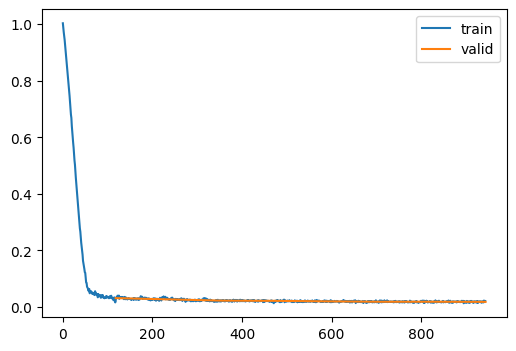

In [52]:
# Train with mixed precision
# Should be noticeably faster than before!
learn.fit(epochs)

In [53]:
# Generate samples with the mixed precision trained model
# Note: We use the standalone sample function here
# Generating a batch of 32 images (batch size of 32)
samples = sample(learn.model, (32, 1, 32, 32), alpha, alphabar, sigma, n_steps)

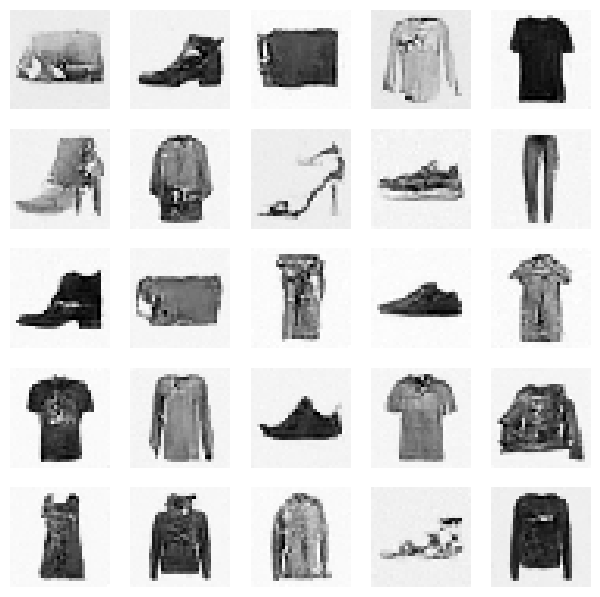

In [54]:
# Display 25 generated images
show_images(samples[-1][:25], imsize=1.5)

In [55]:
# Save the mixed precision trained model
torch.save(learn.model, 'models/fashion_ddpm_mp.pkl')

---

## Section 8: HuggingFace Accelerate

But we don't need to write the mixed precision callback ourselves as Huggingface allows us to do it in a much cleaner way! So, we just defined `MixedPrecision`class, but now we will learn not to writing this function and instead use the `accelerate` library.

**Accelerate** is a library from HuggingFace that simplifies:
- Mixed precision training
- Multi-GPU training
- TPU training

It's a cleaner alternative to writing the mixed precision callback ourselves!

**Installation:**

```bash
pip install accelerate
```

In [56]:
class TrainCB(Callback):
    def __init__(self, n_inp=1): self.n_inp = n_inp
    def predict(self, learn): learn.preds = learn.model(*learn.batch[:self.n_inp])
    def get_loss(self, learn): learn.loss = learn.loss_func(learn.preds, *learn.batch[self.n_inp:])
    def backward(self, learn): learn.loss.backward()
    def step(self, learn): learn.opt.step()
    def zero_grad(self, learn): learn.opt.zero_grad()

In [57]:
#|export
from accelerate import Accelerator

In [58]:
#|export
class AccelerateCB(TrainCB):
    """
    Callback that uses HuggingFace Accelerate for mixed precision and multi-GPU.

    Much simpler than writing MixedPrecision ourselves!

    Parameters:
    -----------
    n_inp : int
        Number of inputs to the model (default 1)
    mixed_precision : str
        "fp16" for half precision, "no" for full precision
    """
    order = DeviceCB.order + 10

    def __init__(self, n_inp=1, mixed_precision="fp16"):
        super().__init__(n_inp=n_inp)
        # Create the Accelerator object
        # This handles all the mixed precision / multi-GPU complexity
        self.acc = Accelerator(mixed_precision=mixed_precision)

    def before_fit(self, learn):
        """
        Prepare model, optimizer, and dataloaders for accelerated training.

        acc.prepare() wraps everything to handle:
        - Moving to correct device
        - Wrapping for mixed precision
        - Wrapping for distributed training (multi-GPU)
        """
        learn.model, learn.opt, learn.dls.train, learn.dls.valid = self.acc.prepare(
            learn.model, learn.opt, learn.dls.train, learn.dls.valid
        )

    def backward(self, learn):
        """
        Use Accelerate's backward which handles gradient scaling.
        """
        self.acc.backward(learn.loss)

**What does the code above do?**

Uses HuggingFace Accelerate to simplify mixed precision training:

**Comparison:**

| Our MixedPrecision CB | AccelerateCB |
|-----------------------|--------------|
| ~30 lines of code | ~15 lines of code |
| Manual scaler management | Automatic |
| Single GPU only | Multi-GPU ready |
| CUDA only | CUDA, CPU, TPU |

**Key method: `acc.prepare()`**

This magical function wraps your model, optimizer, and dataloaders to handle:
- Device placement (GPU/CPU/TPU)
- Mixed precision casting
- Distributed data parallel (multi-GPU)
- Gradient accumulation

In [59]:
# Slightly modified noisify that returns 3 separate values instead of nested tuple
# This works better with Accelerate's data handling
def noisify(x0, alphabar_schedule):
    """
    Modified noisify that returns (xt, t, epsilon) instead of ((xt, t), epsilon).
    """
    device = x0.device
    n = len(x0)
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)
    epsilon = torch.randn(x0.shape, device=device)
    alphabar_t = alphabar_schedule[t].reshape(-1, 1, 1, 1).to(device)
    xt = alphabar_t.sqrt() * x0 + (1 - alphabar_t).sqrt() * epsilon
    return xt, t.to(device), epsilon  # Note: flat tuple, not nested

In [60]:
# Recreate dataloaders with the modified noisify
dls = DataLoaders(dl_ddpm(tds['train']), dl_ddpm(tds['test']))

In [61]:
class DDPMCB2(Callback):
    """
    Simple callback to extract .sample from model output.

    With AccelerateCB, we use the raw UNet2DModel (not our wrapper),
    so we need to extract .sample from the output.
    """
    def after_predict(self, learn):
        learn.preds = learn.preds.sample

# Why `.sample` in `DDPMCB2`

`UNet2DModel.forward()` doesn't return a plain tensor — it returns a **dataclass** called `UNet2DOutput`:

```python
# What UNet2DModel.forward() actually returns:
UNet2DOutput(sample=tensor([...]))
#             ↑ the actual predicted noise tensor is stored here
```

It's essentially a named container:

```python
# Roughly equivalent to:
class UNet2DOutput:
    sample: torch.Tensor   # the predicted noise
```

So without `.sample`:

```python
learn.preds = UNet2DOutput(sample=tensor([...]))   # a dataclass object

MSELoss(learn.preds, noise)   # ❌ crashes — can't do math on a dataclass
```

With `.sample`:

```python
learn.preds = learn.preds.sample   # extracts the raw tensor [B, 1, H, W]

MSELoss(learn.preds, noise)        # ✅ tensor vs tensor
```

---

## Why Does HuggingFace Return a Dataclass at All?

Because `UNet2DModel` is designed to optionally return **multiple things** — not just the
predicted sample, but also intermediate attention weights, hidden states, and other
diagnostic outputs. A dataclass lets them return all of that cleanly under named fields:

```python
UNet2DOutput(
    sample=tensor([...]),          # the predicted noise  ← you want this
    # potentially other fields too
)
```

For DDPM training you only need `.sample`, so that's all you extract.

In [62]:
# Create model (using raw UNet2DModel, not our wrapper)
model = UNet2DModel(
    in_channels=1,
    out_channels=1,
    block_out_channels=(16, 32, 64, 128),
    norm_num_groups=8
)
init_ddpm(model)

# Setup callbacks with AccelerateCB
cbs = [
    DDPMCB2(),                 # Extract .sample from output
    DeviceCB(),                # Device handling (partially redundant with Accelerate)
    ProgressCB(plot=True),
    MetricsCB(),
    BatchSchedCB(sched),
    AccelerateCB(n_inp=2)      # n_inp=2 because model takes (image, timestep)
]

learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=opt_func)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


loss,epoch,train
0.271,0,train
0.035,0,eval
0.029,1,train
0.027,1,eval
0.024,2,train
0.022,2,eval
0.022,3,train
0.021,3,eval
0.021,4,train
0.021,4,eval


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


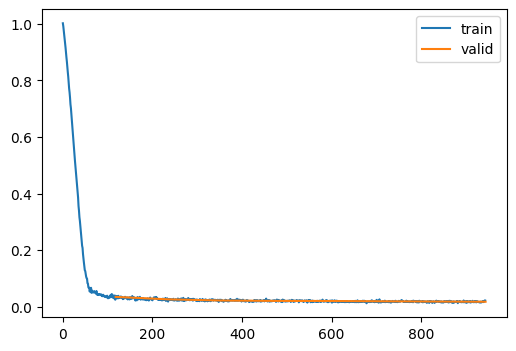

In [63]:
# Train with Accelerate
learn.fit(epochs)

# Understanding `n_inp`, `predict`, and `get_loss` in `TrainCB`

## The Core Problem: A Batch Contains Mixed Things

When a DataLoader yields a batch, it contains **both inputs and targets** bundled together.
The `Learner` stores this as `learn.batch` — a single object.

For DDPM, `collate_ddpm` (via the modified `noisify`) returns a **flat 3-tuple**:

```python
(noisy_images, timesteps, noise)
#  index 0      index 1    index 2
#  └──── model inputs ────┘  └─ target ─┘
```

So `learn.batch` looks like:

```python
learn.batch = (noisy_images, timesteps, noise)
#              index 0        index 1    index 2
```

The `Learner` needs to know: **where do the inputs end and the targets begin?**

That's exactly what `n_inp` answers.

---

## What `n_inp` Means

```python
def __init__(self, n_inp=1): self.n_inp = n_inp
```

`n_inp` is a single integer that acts as a **split point** on `learn.batch`:

```
learn.batch[:n_inp]   →  everything before n_inp  →  model inputs
learn.batch[n_inp:]   →  everything from n_inp on  →  targets for loss
```

For standard image classification (`n_inp=1`):

```python
learn.batch = (images, labels)
#              ↑ index 0      ↑ index 1

learn.batch[:1]  →  (images,)   →  fed to model
learn.batch[1:]  →  (labels,)   →  fed to loss function
```

For DDPM (`n_inp=2`):

```python
learn.batch = (noisy_images, timesteps, noise)
#              ↑ index 0     ↑ index 1   ↑ index 2

learn.batch[:2]  →  (noisy_images, timesteps)  →  fed to model
learn.batch[2:]  →  (noise,)                   →  fed to loss function
```

---

## `predict`: How the Model Gets Called

```python
def predict(self, learn):
    learn.preds = learn.model(*learn.batch[:self.n_inp])
```

With `n_inp=2`, `learn.batch` is `(noisy_images, timesteps, noise)`:

```python
learn.batch[:2]       →  (noisy_images, timesteps)
*learn.batch[:2]      →  noisy_images, timesteps   ← unpacked as 2 separate args

learn.model(noisy_images, timesteps)   ← exactly what UNet2DModel.forward() expects!
```

---

## `get_loss`: How the Loss Gets Computed

```python
def get_loss(self, learn):
    learn.loss = learn.loss_func(learn.preds, *learn.batch[self.n_inp:])
```

```python
learn.batch[2:]       →  (noise,)
*learn.batch[2:]      →  noise          ← unpacked as 1 arg

learn.loss_func(learn.preds, noise)
# = MSELoss(predicted_noise, actual_noise)   ← the DDPM training objective!
```

---

## Why the `*` Unpacking?

Without `*`:

```python
learn.model(learn.batch[:2])
# model receives ONE argument: a tuple (noisy_images, timesteps)
# UNet2DModel.forward() would fail — it expects two separate args
```

With `*`:

```python
learn.model(*learn.batch[:2])
# model receives TWO arguments: noisy_images, timesteps
# UNet2DModel.forward(noisy_images, timesteps) ← works perfectly
```

The `*` is what makes `TrainCB` flexible enough to work for **any model with any number
of inputs** — just change `n_inp`.

---

## Why This Design? The Motivation

`TrainCB` is written to be **universally reusable** across completely different tasks:

| Task | `n_inp` | `learn.batch` | Model call | Loss call |
|---|---|---|---|---|
| Image classification | 1 | `(images, labels)` | `model(images)` | `loss(preds, labels)` |
| DDPM denoising | 2 | `(noisy_imgs, timesteps, noise)` | `model(noisy_imgs, timesteps)` | `loss(preds, noise)` |
| Seq2Seq | 2 | `(src, tgt_in, tgt_out)` | `model(src, tgt_in)` | `loss(preds, tgt_out)` |

The same two lines of code handle all of these — just by changing `n_inp`. Without this
design, you'd need a separate `TrainCB` subclass for every task.

---

## Summary

```python
self.n_inp = n_inp          # Store the split point: inputs vs targets

learn.batch[:self.n_inp]    # Everything up to n_inp  → model inputs
learn.batch[self.n_inp:]    # Everything from n_inp   → loss targets

*learn.batch[:self.n_inp]   # Unpack inputs as separate args to model
*learn.batch[self.n_inp:]   # Unpack targets as separate args to loss function

AccelerateCB(n_inp=2)       # UNet takes 2 inputs: (noisy_image, timestep)
                            # So batch must be: (noisy_imgs, timesteps, noise)
                            #                    ←── 2 inputs ──→  ← 1 target →
```

`n_inp` is a single integer that cleanly separates **"what goes into the model"** from
**"what gets compared against the model's output"** — making `TrainCB` task-agnostic.

# How `forward()` Works: Wrapper vs Raw UNet2DModel

## Two Different Setups, Two Different Approaches

### Setup 1 — The Wrapper (earlier in the notebook)

```python
class UNet(UNet2DModel):
    def forward(self, x):
        return super().forward(*x).sample

model = UNet(...)
```

The model receives `x` as a **single tuple** `(noisy_image, timestep)`, unpacks it,
calls the parent forward, and extracts `.sample`. One object in, one tensor out.

---

### Setup 2 — Raw UNet2DModel (with AccelerateCB)

```python
model = UNet2DModel(...)
```

No wrapper. No custom `forward`. The raw HuggingFace model is used directly. So how
does it get called correctly?

---

## Tracing the Call Chain

With `AccelerateCB(n_inp=2)`, the batch is:

```python
learn.batch = (noisy_images, timesteps, noise)
#              index 0        index 1    index 2
```

`TrainCB.predict` fires:

```python
def predict(self, learn):
    learn.preds = learn.model(*learn.batch[:self.n_inp])
```

With `n_inp=2`:

```python
learn.batch[:2]       →  (noisy_images, timesteps)
*learn.batch[:2]      →  noisy_images,  timesteps   ← unpacked as 2 separate args

learn.model(noisy_images, timesteps)
# calls UNet2DModel.forward(noisy_images, timesteps) directly
```

`UNet2DModel.forward()` signature (from HuggingFace Diffusers):

```python
def forward(
    self,
    sample: torch.Tensor,       # the noisy image
    timestep: torch.Tensor,     # the timestep
    ...
) -> UNet2DOutput:
```

So `noisy_images` lands on `sample` and `timesteps` lands on `timestep`. Exactly right.

---

## But Now `learn.preds` is a Dataclass, Not a Tensor

`UNet2DModel.forward()` returns `UNet2DOutput`, not a raw tensor:

```python
learn.preds = UNet2DOutput(sample=tensor([...]))
#                           ↑ the actual noise prediction is buried here
```

If we now compute loss:

```python
learn.loss = MSELoss(learn.preds, noise)
# ❌ fails — can't compare a dataclass to a tensor
```

This is exactly why `DDPMCB2` exists:

```python
class DDPMCB2(Callback):
    def after_predict(self, learn):
        learn.preds = learn.preds.sample
```

It fires immediately after `predict`, extracting `.sample` from the dataclass:

```python
learn.preds = learn.preds.sample
# learn.preds is now a plain tensor: [B, 1, H, W]
```

Now the loss computation works correctly:

```python
learn.loss = MSELoss(learn.preds, noise)   # ✅ tensor vs tensor
```

---

## Side-by-Side Comparison

| | Wrapper `UNet` | Raw `UNet2DModel` |
|---|---|---|
| Model class | Custom subclass | HuggingFace directly |
| `forward` input | Single tuple `(image, t)` | Two separate args `image, t` |
| `forward` output | Plain tensor | `UNet2DOutput` dataclass |
| `.sample` extraction | Inside `forward()` | Done by `DDPMCB2.after_predict()` |
| `n_inp` needed | 1 (tuple counts as one) | 2 (image and timestep are separate) |

---

## The Full Sequence Per Batch

```
TrainCB.predict
    learn.model(*learn.batch[:2])
    → UNet2DModel.forward(noisy_images, timesteps)
    → returns UNet2DOutput(sample=predicted_noise)
    → learn.preds = UNet2DOutput(...)        ← still a dataclass

DDPMCB2.after_predict
    learn.preds = learn.preds.sample         ← now a plain tensor [B, 1, H, W]

TrainCB.get_loss
    MSELoss(learn.preds, noise)              ← tensor vs tensor ✅
```

The wrapper approach folded everything into `forward()` itself. The raw approach splits
the responsibility: `TrainCB` handles the call, `DDPMCB2` handles the extraction.
Both arrive at exactly the same result.

# How Callback `order` Works in the Learner

## What `order` Actually Controls

`order` does **not** mean "this callback runs last overall." It controls the **sort position**
of the callback in the list — which determines the sequence when **the same hook fires across
multiple callbacks**.

The Learner sorts all callbacks by their `order` value once at the start:

```python
# Internally, Learner does something like:
self.cbs = sorted(cbs, key=lambda cb: cb.order)
```

Then, whenever a hook fires (e.g. `before_fit`), it iterates through that **sorted list** and
calls the hook on each callback **that defines it**, in order.

---

## The Order Values

| Callback | `order` value |
|---|---|
| `DDPMCB2` | 0 (default) |
| `DeviceCB` | some value, e.g. 10 |
| `ProgressCB` | some value |
| `MetricsCB` | some value |
| `BatchSchedCB` | some value |
| `AccelerateCB` | `DeviceCB.order + 10` ← always runs **after** DeviceCB |

`AccelerateCB.order = DeviceCB.order + 10` means one specific thing:

> **AccelerateCB's hooks always fire after DeviceCB's hooks** — for every shared hook.

That's it. It says nothing about ProgressCB, MetricsCB, etc.

---

## Walking Through `before_fit` Step by Step

When `learn.fit(epochs)` is called, the Learner fires `before_fit` across all callbacks
in sorted order. Only callbacks that **define** `before_fit` respond:

```
Sorted callback list fires before_fit:

DDPMCB2        → no before_fit defined → skip
DeviceCB       → has before_fit? → calls it   (moves model to GPU)
ProgressCB     → has before_fit? → calls it   (sets up progress bar)
MetricsCB      → has before_fit? → calls it   (initializes metric tracking)
BatchSchedCB   → has before_fit? → calls it   (sets up scheduler)
AccelerateCB   → has before_fit defined → calls it  ← runs LAST among those that have it
                    └── acc.prepare(model, opt, dls.train, dls.valid)
                        wraps model/opt/dataloaders for mixed precision + multi-GPU
```

`AccelerateCB.before_fit` runs last **among the callbacks that define `before_fit`** —
which is exactly what you want. `acc.prepare()` needs the model and optimizer to already
exist and be on the right device before wrapping them.

---

## Why the Order Between DeviceCB and AccelerateCB Matters

This is the real reason for `DeviceCB.order + 10`:

```
DeviceCB.before_fit  →  moves model to GPU
                              ↓
AccelerateCB.before_fit  →  acc.prepare(model, ...)
                              wraps the already-GPU model for mixed precision
```

If AccelerateCB ran **before** DeviceCB, `acc.prepare()` would wrap a CPU model.
The `+ 10` guarantees the right sequence.

---

## The General Pattern for Any Hook

This same logic applies to **every hook**, not just `before_fit`:

```
For hook X, the Learner does:

for cb in sorted_callbacks:
    if hasattr(cb, 'X'):
        cb.X(learn)
```

So for `backward`:

```
DDPMCB2        → no backward → skip
DeviceCB       → no backward → skip
ProgressCB     → no backward → skip
MetricsCB      → no backward → skip
BatchSchedCB   → no backward → skip
AccelerateCB   → has backward → calls self.acc.backward(learn.loss)
```

Only AccelerateCB defines `backward`, so it's the only one that runs.

---

## Summary

| Misconception | Reality |
|---|---|
| `order` controls when a callback runs overall | `order` controls the **sequence within each hook** |
| AccelerateCB runs last for everything | AccelerateCB runs last only among callbacks **that define the same hook** |
| `before_fit` blocks all other callbacks | Each callback's `before_fit` fires independently, in `order` sequence |

The `order` system is a **per-hook sequencing mechanism**, not a global execution priority.
It lets the framework guarantee fine-grained dependencies (e.g. "device setup before
acceleration wrapping") without coupling the callbacks to each other.

---

## Section 9: A Sneaky Trick - Data Multiplication

Here's a clever trick: repeat each batch multiple times! This can improve training because:
- Each image gets noisified with different random timesteps
- More training steps without loading more data
- Effectively data augmentation for diffusion models

In [64]:
class MultDL:
    """
    A wrapper class for a DataLoader that replicates each batch multiple times
    within a single iteration cycle (epoch).

    This is helpful in deep learning workflows where:
    1. Stochastic Augmentation: If the DataLoader or Model applies random transforms
       on-the-fly, yielding the same batch multiple times allows the model to see
       different 'views' of the same underlying data in quick succession.
    2. Training Stability: It can effectively increase the 'epoch' length for
       learning rate schedulers or logging without requiring more physical data.
    3. Efficiency: It reuses the data 'o' already loaded into memory/GPU multiple
       times before fetching the next batch, potentially reducing I/O overhead.
    """
    def __init__(self, dl, mult=2):
        self.dl = dl
        self.mult = mult

    def __len__(self):
        # The total number of batches seen by the trainer is now scaled by 'mult'.
        # This ensures progress bars and schedulers correctly reflect the extended iteration.
        return len(self.dl) * self.mult

    # __iter__ is called when we call a for loop
    def __iter__(self):
        """
        The __iter__ method defines how the object is traversed in a loop.

        We define it this way to intercept the standard DataLoader flow:
        1. 'for o in self.dl': Fetches a single batch (o) from the original source.
        2. 'for i in range(self.mult): yield o': Instead of returning 'o' once,
           the generator 'yields' (emits) the exact same batch object 'mult' times.

        By yielding multiple times here, the training loop receiving this data
        will process the same batch repeatedly. If there are stochastic elements
        (like dropout or random noise) in the model's forward pass, the model
        learns from different perturbations of the same batch back-to-back.
        """
        for o in self.dl:
            for i in range(self.mult):
                yield o

**What does the code above do?**

Creates a wrapper that repeats each batch:

```
Original DataLoader:      MultDL(dl, mult=2):
batch_1                   batch_1
batch_2                   batch_1  (repeat!)
batch_3                   batch_2
...                       batch_2  (repeat!)
                          batch_3
                          batch_3  (repeat!)
                          ...
```

**Why is this useful for DDPM?**

Each time we see the same image, it gets:
- A different random timestep
- Different random noise

So it's actually different training data each time! This is like free data augmentation.

### 🎮 Pointer: watch `MultDL` in the pipeline visualization

Now that you know what `MultDL` does, **scroll back up to the 🎮 data-pipeline visualization in Section 7** and toggle **"MultDL ×2" on**: each delivered batch gets consumed twice by the GPU while the workers get breathing room. Notice the trade-off: steps-per-epoch doubles, but the two passes reuse the *same* frozen (x_t, t, ε) — only the model weights (and dropout/optimizer state) differ between them.

In [65]:
# Apply the multiplier to the training DataLoader
# Now each epoch sees each batch twice
dls.train = MultDL(dls.train)

---

## Section 10: Export

Export the notebook cells marked with `#|export` to a Python module.

In [67]:
# Export marked cells to miniai/accel.py
# import nbdev
# nbdev.nbdev_export()

---

## Summary

This notebook covered several important improvements to DDPM training:

---

**1. Better Data Preprocessing**
- Padding instead of resizing preserves image quality

**2. Custom Collate Function**
- Noisify during data loading (parallel with GPU)
- More efficient pipeline

**3. Weight Initialization**
- Zero init for residual outputs → stable training
- Orthogonal init for downsampling → gradient preservation

**4. Mixed Precision Training**
- FP16 for most operations
- GradScaler prevents underflow
- 2x faster, 2x less memory

**5. HuggingFace Accelerate**
- Simplifies mixed precision code
- Ready for multi-GPU
- One-line setup with `acc.prepare()`

**6. Data Multiplication Trick**
- Repeat batches for more training
- Different noise each time = data augmentation

---

**Key Takeaways:**

| Technique | Benefit |
|-----------|--------|
| Custom collate | Parallel noisification |
| Zero init | Stable training start |
| Mixed precision | 2x faster, bigger batches |
| Accelerate | Cleaner code, multi-GPU ready |
| MultDL | Free data augmentation |

---

**🎮 Interactive companions:** this notebook ships with eight interactive visualizations (big picture, noise schedule lab, noisify machine, 3D diffusion, sampling walk, GroupNorm explorer, mixed precision lab, and the data pipeline). If a concept ever feels fuzzy, scroll back to the nearest 🎮 cell and *drive* the idea instead of reading it.